# FinResearch Agent — mô hình dự báo tăng trưởng doanh thu

Notebook này làm trọn phần ML của project:

1. Tải bộ `vduydong/ocr_annual_financials` (BCTC kiểm toán 2015–2025, bản OCR) và trích số liệu theo mã số Thông tư 200.
2. Dựng bảng đặc trưng: mỗi dòng là một công ty trong một năm.
3. Train XGBoost dự báo **tăng trưởng doanh thu năm sau so với mặt bằng chung**, so với baseline, đánh giá theo thời gian.
4. Khoảng dự báo bằng conformal prediction.
5. Giải thích bằng SHAP và đo độ ổn định của lời giải thích qua bootstrap.
6. Dự báo 2026 và lưu artifact để app dùng lại.

**Chạy trên Kaggle:** bật *Internet* trong Settings rồi Run All. Không cần GPU. Lần chạy đầu mất khoảng 10–15 phút, phần lớn là tải và trích dữ liệu.

## 0. Mã nguồn xử lý dữ liệu

Các ô dưới đây ghi package `finresearch` và bảng tham chiếu mã chứng khoán ra đĩa, để notebook chạy được mà không cần clone repo. Chúng được sinh tự động từ repo bằng `scripts/make_notebook.py`; muốn sửa thì sửa trong repo rồi sinh lại.

In [6]:
import os

for d in ("finresearch", "reference"):
    os.makedirs(d, exist_ok=True)

In [7]:
%%writefile finresearch/__init__.py
"""FinResearch Agent: statement extraction and feature building."""


Overwriting finresearch/__init__.py


In [8]:
%%writefile finresearch/extract.py
"""Extract coded financial statement lines from OCR'd Vietnamese audited reports.

Input is one `*_extracted.txt` file from the `vduydong/ocr_annual_financials`
dataset. The statements appear as HTML tables whose rows carry the line code
("Mã số") defined by Circular 200/2014/TT-BTC, plus a current-year and a
prior-year amount. The code column, the label layout and the number format all
vary between auditors, so nothing here assumes a fixed column position.
"""
from __future__ import annotations

import re
import unicodedata
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path

TABLE_RE = re.compile(r"<table.*?</table>", re.S | re.I)
TR_RE = re.compile(r"<tr[^>]*>(.*?)</tr>", re.S | re.I)
TD_RE = re.compile(r"<t[dh]([^>]*)>(.*?)</t[dh]>", re.S | re.I)
SPAN_RE = re.compile(r"(row|col)span\s*=\s*[\"']?(\d+)", re.I)
TAG_RE = re.compile(r"<[^>]+>")
CODE_RE = re.compile(r"^\d{1,3}[a-zA-Z]?$")
GROUPED_RE = re.compile(r"^\d{1,3}([.,]\d{3})+$")
DECIMAL_RE = re.compile(r"^\d+[.,]\d{1,2}$")
YEAR_RE = re.compile(r"(?<!\d)(20[0-3]\d)(?!\d)")

CONTEXT_LINES = 8


def fold(s: str) -> str:
    """Lowercase and strip diacritics so OCR accent errors do not matter."""
    s = s.replace("đ", "d").replace("Đ", "D")
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")
    return re.sub(r"\s+", " ", s).lower().strip()


def parse_number(cell: str) -> float | None:
    """Parse an amount cell. Returns None when the cell is not an amount.

    Handles `1.234.567`, `1,234,567`, `(1.234)`, `-1.234` and a lone dash (nil).
    """
    s = cell.strip().replace("\xa0", "").replace(" ", "")
    if not s:
        return None
    if s in {"-", "–", "—", "_", "0"}:
        return 0.0
    neg = False
    if s.startswith("(") and s.endswith(")"):
        neg, s = True, s[1:-1]
    elif s.startswith("(") or s.endswith(")"):
        neg, s = True, s.strip("()")
    if s[:1] in "-–—":
        neg, s = True, s[1:]
    if GROUPED_RE.match(s):
        v = float(re.sub(r"[.,]", "", s))
    elif s.isdigit():
        v = float(s)
    elif DECIMAL_RE.match(s):
        v = float(s.replace(",", "."))
    else:
        return None
    return -v if neg else v


@dataclass
class Table:
    rows: list[list[str]]
    context: str  # folded text of the lines just above the table
    line: int


def _grid(table_html: str) -> list[list[str]]:
    """Expand rowspan/colspan so every row has the same column positions."""
    grid: list[list[str]] = []
    carry: dict[int, tuple[int, str]] = {}  # col -> (rows left, text)
    for tr in TR_RE.findall(table_html):
        row: list[str] = []
        col = 0
        cells = TD_RE.findall(tr)
        for attrs, inner in cells:
            while col in carry:
                left, _ = carry[col]
                row.append("")
                carry[col] = (left - 1, "")
                if carry[col][0] <= 0:
                    del carry[col]
                col += 1
            spans = {k.lower(): int(v) for k, v in SPAN_RE.findall(attrs)}
            text = re.sub(r"\s+", " ", TAG_RE.sub(" ", inner)).strip()
            cs, rs = max(spans.get("col", 1), 1), max(spans.get("row", 1), 1)
            for k in range(cs):
                row.append(text if k == 0 else "")
                if rs > 1:
                    carry[col] = (rs - 1, "")
                col += 1
        while col in carry:
            left, _ = carry[col]
            row.append("")
            carry[col] = (left - 1, "")
            if carry[col][0] <= 0:
                del carry[col]
            col += 1
        if row:
            grid.append(row)
    return grid


def iter_tables(text: str):
    for m in TABLE_RE.finditer(text):
        rows = _grid(m.group(0))
        if not rows:
            continue
        before = TABLE_RE.sub(" ", text[max(0, m.start() - 3000):m.start()])
        ctx = [l.strip() for l in before.split("\n") if l.strip()]
        context = fold(" // ".join(ctx[-CONTEXT_LINES:]))
        yield Table(rows=rows, context=context, line=text.count("\n", 0, m.start()))


CODE_HEADER_RE = re.compile(r"\bma ?so\b|^ms$|^m\.?s\.?$|\bcodes?\b|^ma$")


def find_code_col(rows: list[list[str]]) -> int | None:
    """Column that holds the line code, or None if the table has no codes."""
    width = max(len(r) for r in rows)
    counts = Counter()
    for r in rows:
        for j, c in enumerate(r[: min(width, 5)]):
            if CODE_RE.match(c.strip()):
                counts[j] += 1
    if not counts or max(counts.values()) < 3:
        return None
    for r in rows[:3]:  # a header naming the column wins over content counts
        for j, c in enumerate(r[: min(width, 5)]):
            if CODE_HEADER_RE.search(fold(c)) and counts.get(j, 0) >= 3:
                return j
    best = max(counts.values())
    # The note column also holds small integers; it is sparser and to the right.
    return min(j for j, n in counts.items() if n >= 0.8 * best)


CUR_HINT = re.compile(r"cuoi nam|cuoi ky|nam nay|ky nay|so cuoi|closing|current year|ending")
PREV_HINT = re.compile(r"dau nam|dau ky|nam truoc|ky truoc|so dau|opening|previous year|prior year|beginning")


def find_value_cols(rows: list[list[str]], code_col: int) -> tuple[int, int, bool] | None:
    """Return (cur_col, prev_col, order_from_header) for a coded table."""
    width = max(len(r) for r in rows)
    coded = [r for r in rows if len(r) > code_col and CODE_RE.match(r[code_col].strip())]
    numeric = Counter()
    for r in coded:
        for j in range(code_col + 1, min(len(r), width)):
            v = parse_number(r[j])
            # amounts only: note references such as "5" or "V.1" must not count
            if v is not None and (abs(v) >= 1000 or r[j].strip() in {"-", "–", "—"}):
                numeric[j] += 1
    cols = sorted(j for j, n in numeric.items() if n >= max(2, 0.3 * len(coded)))
    if len(cols) < 2:
        return None
    a, b = cols[-2], cols[-1]

    header = [r for r in rows[:4] if not (len(r) > code_col and CODE_RE.match(r[code_col].strip()))]
    ha = fold(" ".join(r[a] for r in header if len(r) > a))
    hb = fold(" ".join(r[b] for r in header if len(r) > b))
    ya = [int(y) for y in YEAR_RE.findall(ha)]
    yb = [int(y) for y in YEAR_RE.findall(hb)]
    if ya and yb and max(ya) != max(yb):
        return (a, b, True) if max(ya) > max(yb) else (b, a, True)
    if PREV_HINT.search(ha) and CUR_HINT.search(hb):
        return b, a, True
    if CUR_HINT.search(ha) and PREV_HINT.search(hb):
        return a, b, True
    return a, b, False


BS_TITLE = re.compile(r"can doi ke toan|balance sheet|financial position|tinh hinh tai chinh|b ?01")
IS_TITLE = re.compile(r"ket qua (hoat dong )?kinh doanh|income statement|profit (or|and) loss|b ?02")
CF_TITLE = re.compile(r"luu chuyen tien|cash flow|b ?03")
IS_WORDS = re.compile(
    r"doanh thu ban hang|doanh thu thuan|gia von|loi nhuan gop|chi phi ban hang|chi phi quan ly|"
    r"thu nhap khac|lai co ban|lai suy giam|chi phi thue|net revenue|net sales|cost of|gross profit|"
    r"selling expense|administrati|earnings per share|other income"
)
CF_WORDS = re.compile(
    r"luu chuyen|khau hao|tien chi|tien thu|tang,? ?giam|\(tang\)|tien va (cac khoan )?tuong duong|"
    r"cash flow|net cash|depreciation|payments? |proceeds|increase|decrease|cash and cash equivalents at"
)


LETTERS_RE = re.compile(r"[^\W\d_]")


def row_label(row: list[str], code_col: int) -> str:
    """Text of a row: every cell that reads as words, whichever side of the code it is on."""
    parts = [c for j, c in enumerate(row) if j != code_col and len(LETTERS_RE.findall(c)) >= 3]
    return " ".join(parts).strip()


def classify(rows: list[list[str]], code_col: int, context: str) -> str | None:
    """Decide whether a coded table is a balance sheet, income statement or cash flow."""
    codes, labels = [], []
    for r in rows:
        if len(r) > code_col and CODE_RE.match(r[code_col].strip()):
            codes.append(r[code_col].strip())
            labels.append(fold(row_label(r, code_col)))
    if len(codes) < 3:
        return None
    three_digit = sum(1 for c in codes if len(re.sub(r"\D", "", c)) == 3)
    if three_digit >= 0.6 * len(codes):
        return "BS"
    if three_digit > 0.3 * len(codes):
        return None  # mixed codes: not one of the three statements
    is_score = sum(1 for l in labels if IS_WORDS.search(l))
    cf_score = sum(1 for l in labels if CF_WORDS.search(l))
    tail = context[-260:]
    if IS_TITLE.search(tail) and not CF_TITLE.search(tail):
        is_score += 2
    if CF_TITLE.search(tail) and not IS_TITLE.search(tail):
        cf_score += 2
    if is_score == cf_score == 0:
        return None
    return "IS" if is_score > cf_score else "CF"


UNIT_PATTERNS = [
    (re.compile(r"ty (dong|vnd)|billion"), 1e9),
    (re.compile(r"trieu (dong|vnd)|million|vnd ?million|tr\.? ?d\b"), 1e6),
    (re.compile(r"(nghin|ngan|1\.000|1000) (dong|vnd)|thousand|'000"), 1e3),
]


def detect_unit(text: str) -> float:
    for pat, mult in UNIT_PATTERNS:
        if pat.search(text):
            return mult
    return 1.0


# Total rows are sometimes printed without a code; recover them from the label.
LABEL_CODES = {
    "BS": [
        (re.compile(r"^tong (cong )?tai san\b|^total assets"), "270"),
        (re.compile(r"^tong (cong )?nguon von\b|^total (resources|liabilities and)"), "440"),
    ],
}

# Labels a key code must carry in a Circular 200 statement. Banks, brokers and
# insurers reuse the same numbers for different lines and fail this check.
KEY_LABELS = {
    "IS": {
        "10": r"doanh thu thuan|net revenue|net sales|net turnover",
        "11": r"gia von|cost of",
        "20": r"loi nhuan gop|lo gop|gross",
        "50": r"truoc thue|before tax",
        "60": r"sau thue|after tax|net profit|profit for the",
    },
    "BS": {
        "100": r"ngan han|current assets",
        "200": r"dai han|non-?current|long-?term",
        "270": r"tong (cong )?tai san|total assets",
        "300": r"no phai tra|liabilities",
        "400": r"von chu so huu|equity|nguon von",
        "440": r"tong (cong )?nguon von|total",
    },
    "CF": {
        "20": r"hoat dong (san xuat,? ?)?kinh doanh|operating",
        "30": r"dau tu|investing",
        "40": r"tai chinh|financing",
    },
}


def norm_code(c: str) -> str:
    c = c.strip().lower()
    digits = re.sub(r"\D", "", c)
    suffix = c[len(digits):]
    if len(digits) == 1:
        digits = "0" + digits
    return digits + suffix


@dataclass
class Statement:
    lines: dict[str, tuple[str, float | None, float | None]] = field(default_factory=dict)
    unit: float = 1.0
    order_from_header: bool = False
    n_tables: int = 0
    title: str = ""

    def get(self, code: str, which: int) -> float | None:
        v = self.lines.get(code)
        return None if v is None else v[1 + which]


@dataclass
class Report:
    statements: dict[str, Statement]
    n_tables: int
    n_coded_tables: int
    consolidated_title: bool
    english: bool

    def label_match(self, kind: str) -> float:
        """Share of key codes whose label matches the Circular 200 wording."""
        st = self.statements.get(kind)
        if st is None:
            return 0.0
        keys = KEY_LABELS[kind]
        hits = sum(1 for c, pat in keys.items() if c in st.lines and re.search(pat, fold(st.lines[c][0])))
        return hits / len(keys)


def extract_report(text: str) -> Report:
    statements: dict[str, Statement] = {}
    n_tables = n_coded = 0
    for table in iter_tables(text):
        n_tables += 1
        code_col = find_code_col(table.rows)
        if code_col is None:
            continue
        kind = classify(table.rows, code_col, table.context)
        value_cols = find_value_cols(table.rows, code_col)
        if kind is None or value_cols is None:
            continue
        n_coded += 1
        cur_col, prev_col, from_header = value_cols
        st = statements.setdefault(kind, Statement())
        if st.n_tables == 0:
            header_text = fold(" ".join(" ".join(r) for r in table.rows[:3]))
            st.unit = detect_unit(table.context[-200:] + " " + header_text)
            st.order_from_header = from_header
            st.title = table.context[-200:]
        st.n_tables += 1
        for r in table.rows:
            if len(r) <= max(code_col, cur_col, prev_col):
                continue
            raw = r[code_col].strip()
            label = row_label(r, code_col)
            if CODE_RE.match(raw):
                code = norm_code(raw)
            else:
                code = next((c for pat, c in LABEL_CODES.get(kind, []) if pat.search(fold(label))), None)
                if code is None:
                    continue
            if code in st.lines:  # keep the first occurrence; later ones are repeats
                continue
            st.lines[code] = (label, parse_number(r[cur_col]), parse_number(r[prev_col]))
    head = fold(text[:4000])
    titles = " ".join(s.title for s in statements.values())
    return Report(
        statements=statements,
        n_tables=n_tables,
        n_coded_tables=n_coded,
        consolidated_title=bool(re.search(r"hop nhat|consolidated", titles + " " + head)),
        english=bool(re.search(r"balance sheet|financial position|income statement", titles)),
    )


def extract_file(path: str | Path) -> Report:
    return extract_report(Path(path).read_text(encoding="utf-8", errors="replace"))


Overwriting finresearch/extract.py


In [9]:
%%writefile finresearch/build.py
"""Run the extractor over the whole dataset and pick one report per ticker-year."""
from __future__ import annotations

import re
import subprocess
from multiprocessing import Pool
from pathlib import Path

import numpy as np
import pandas as pd

from .extract import extract_file, fold

KINDS = ("BS", "IS", "CF")
CONSOLIDATED_NAME = re.compile(r"hop ?nhat|hopnhat|consolidat|(?<![a-z])hn(?![a-z])")
PARENT_NAME = re.compile(r"cong ?ty ?me|congtyme|rieng|separate|tong ?hop|(?<![a-z])me(?![a-z])")


def _rel_err(a, b) -> float:
    """Relative gap between two amounts that should be equal; nan if either is missing."""
    if a is None or b is None:
        return np.nan
    scale = max(abs(a), abs(b))
    return 0.0 if scale == 0 else abs(a - b) / scale


def _sum(st, codes, which):
    vals = [st.get(c, which) for c in codes]
    if vals[0] is None:
        return None
    return sum(v or 0.0 for v in vals)


def identity_errors(report) -> dict[str, float]:
    """Accounting identities, worst of the two year columns. Small means consistent."""
    out = {}
    bs, is_, cf = (report.statements.get(k) for k in KINDS)
    worst = lambda errs: np.nan if all(np.isnan(e) for e in errs) else np.nanmax(errs)
    if bs:
        out["err_assets"] = worst([_rel_err(bs.get("270", w), _sum(bs, ["100", "200"], w)) for w in (0, 1)])
        out["err_funding"] = worst([_rel_err(bs.get("440", w), _sum(bs, ["300", "400"], w)) for w in (0, 1)])

        def balance(w):  # a total row is sometimes lost in OCR, so accept the sum of its parts
            assets = [bs.get("270", w), _sum(bs, ["100", "200"], w)]
            funding = [bs.get("440", w), _sum(bs, ["300", "400"], w)]
            errs = [_rel_err(a, f) for a in assets for f in funding]
            return np.nan if all(np.isnan(e) for e in errs) else np.nanmin(errs)

        out["err_balance"] = worst([balance(w) for w in (0, 1)])
    if is_:
        # cost of sales is printed as a positive amount by some auditors and in brackets by others
        gross = lambda w: None if is_.get("10", w) is None else is_.get("10", w) - abs(is_.get("11", w) or 0.0)
        out["err_gross"] = worst([_rel_err(is_.get("20", w), gross(w)) for w in (0, 1)])
    if cf:
        out["err_cash"] = worst([_rel_err(cf.get("50", w), _sum(cf, ["20", "30", "40"], w)) for w in (0, 1)])
    return out


def parse_path(path: Path, raw_dir: Path) -> dict:
    ticker, year, stem = path.relative_to(raw_dir).parts[:3]
    name = fold(stem.replace("_", " ").replace("-", " ").replace(".", " "))
    if CONSOLIDATED_NAME.search(name):
        scope = "consolidated"
    elif PARENT_NAME.search(name):
        scope = "parent"
    else:
        scope = "unknown"
    return {"ticker": ticker, "year": int(year), "file": str(path.relative_to(raw_dir)), "name_scope": scope}


def process_file(args) -> tuple[dict, list[tuple]]:
    path, raw_dir = args
    meta = parse_path(path, raw_dir)
    try:
        report = extract_file(path)
    except Exception as exc:  # one broken file must not stop an 18k-file run
        meta["error"] = f"{type(exc).__name__}: {exc}"[:200]
        return meta, []
    meta.update(
        n_tables=report.n_tables,
        n_coded_tables=report.n_coded_tables,
        consolidated_title=report.consolidated_title,
        english=report.english,
        **identity_errors(report),
    )
    rows = []
    for kind in KINDS:
        st = report.statements.get(kind)
        meta[f"n_{kind}"] = len(st.lines) if st else 0
        meta[f"label_{kind}"] = report.label_match(kind)
        if st:
            meta[f"unit_{kind}"] = st.unit
            for code, (label, cur, prev) in st.lines.items():
                rows.append((meta["file"], kind, code, label[:80], cur, prev))
    return meta, rows


def extract_all(raw_dir: str | Path, workers: int = 4, limit: int | None = None):
    """Return (reports, facts): one row per file, and one row per extracted line."""
    raw_dir = Path(raw_dir)
    files = sorted(raw_dir.glob("*/*/*/*_extracted.txt"))[:limit]
    jobs = [(p, raw_dir) for p in files]
    if workers > 1:
        with Pool(workers) as pool:
            results = pool.map(process_file, jobs, chunksize=32)
    else:
        results = [process_file(j) for j in jobs]
    reports = pd.DataFrame([m for m, _ in results])
    facts = pd.DataFrame(
        [r for _, rows in results for r in rows],
        columns=["file", "statement", "code", "label", "cur", "prev"],
    )
    return reports, facts


TOL = 0.005  # identities must hold within 0.5%


def grade_reports(reports: pd.DataFrame) -> pd.DataFrame:
    """Add quality flags and the final scope of each report."""
    r = reports.copy()
    for col in ("err_assets", "err_funding", "err_balance", "err_gross", "err_cash"):
        if col not in r:
            r[col] = np.nan
    r["bs_ok"] = (r.err_balance <= TOL) & (r.label_BS >= 0.6)
    r["is_ok"] = (r.err_gross <= TOL) & (r.label_IS >= 0.8)
    r["cf_ok"] = (r.err_cash <= TOL) & (r.label_CF >= 0.6)
    # Circular 200 layout: excludes banks, brokers and insurers.
    r["corporate"] = (r.label_IS >= 0.8) & (r.label_BS >= 0.6)

    scope = r.name_scope.where(r.name_scope != "unknown", np.where(r.consolidated_title, "consolidated", "unknown"))
    # A ticker that ever files consolidated statements is a group, so its
    # other statements are the parent company's own accounts.
    is_group = scope.eq("consolidated").groupby(r.ticker).transform("any")
    r["scope"] = np.where(scope == "consolidated", "consolidated", np.where(is_group, "parent", "single"))
    r["quality"] = r.bs_ok.astype(int) + r.is_ok.astype(int) + r.cf_ok.astype(int)
    return r


def select_reports(graded: pd.DataFrame) -> pd.DataFrame:
    """One report per ticker-year: consolidated first, then best quality."""
    rank = graded.scope.map({"consolidated": 0, "single": 0, "parent": 1})
    g = graded.assign(_rank=rank, _lines=graded.n_BS + graded.n_IS + graded.n_CF)
    g = g[g.corporate].sort_values(
        ["ticker", "year", "_rank", "quality", "english", "_lines"],
        ascending=[True, True, True, False, True, False],
    )
    return g.drop_duplicates(["ticker", "year"]).drop(columns=["_rank", "_lines"])


DATASET_URL = "https://huggingface.co/datasets/vduydong/ocr_annual_financials"


def download_raw(raw_dir: str | Path) -> Path:
    """Shallow git clone: one request instead of 18k file downloads."""
    raw_dir = Path(raw_dir)
    if not any(raw_dir.glob("*/*/*/*_extracted.txt")):
        raw_dir.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["git", "clone", "--depth", "1", DATASET_URL, str(raw_dir)], check=True)
    return raw_dir


def build_dataset(raw_dir: str | Path, out_dir: str | Path, companies_csv: str | Path | None = None, workers: int = 4):
    """Extract, grade, select and assemble. Writes parquet files and returns the panel."""
    from .panel import build_panel

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    reports, facts = extract_all(raw_dir, workers=workers)
    graded = grade_reports(reports)
    selected = select_reports(graded)
    companies = pd.read_csv(companies_csv) if companies_csv and Path(companies_csv).exists() else None
    panel = build_panel(facts, selected, companies)
    graded.to_parquet(out_dir / "reports.parquet", index=False)
    facts[facts.file.isin(selected.file)].to_parquet(out_dir / "facts.parquet", index=False)
    panel.to_parquet(out_dir / "panel.parquet", index=False)
    return graded, selected, panel


Overwriting finresearch/build.py


In [10]:
%%writefile finresearch/panel.py
"""Turn extracted statement lines into one row per ticker-year with model features.

Every ratio and growth rate is computed inside a single report, from its
current-year and prior-year columns. That keeps a firm's numbers on one unit
and one restatement basis, so differences between reports cannot leak into a
feature. The target is next year's revenue growth, read the same way from the
following year's report.
"""
from __future__ import annotations

import re

import numpy as np
import pandas as pd

from .extract import fold

# name: (statement, candidate codes in order of preference, pattern the label must match)
FIELDS: dict[str, tuple[str, tuple[str, ...], str | None]] = {
    "revenue": ("IS", ("10",), r"doanh thu thuan|net revenue|net sales|net turnover"),
    "cogs": ("IS", ("11",), r"gia von|cost of"),
    "gross_profit": ("IS", ("20",), r"gop|gross"),
    "fin_income": ("IS", ("21",), r"tai chinh|financ"),
    "fin_expense": ("IS", ("22",), r"tai chinh|financ"),
    "interest_expense": ("IS", ("23",), r"lai vay|interest"),
    # code 24 is selling expense in separate statements and share of associates in consolidated ones
    "selling_exp": ("IS", ("25", "24"), r"ban hang|selling"),
    "admin_exp": ("IS", ("26", "25"), r"quan ly|administrat"),
    "op_profit": ("IS", ("30",), r"hoat dong kinh doanh|operating"),
    "pbt": ("IS", ("50",), r"truoc thue|before tax"),
    "net_income": ("IS", ("60",), r"sau thue|after tax|net profit|profit for the"),
    "current_assets": ("BS", ("100",), r"ngan han|current"),
    "cash": ("BS", ("110",), r"tien|cash"),
    "st_investments": ("BS", ("120",), r"dau tu|investment"),
    "st_receivables": ("BS", ("130",), r"phai thu|receivable"),
    "trade_receivables": ("BS", ("131",), r"phai thu|receivable"),
    "inventory": ("BS", ("140",), r"ton kho|inventor"),
    "noncurrent_assets": ("BS", ("200",), r"dai han|non-?current|long-?term"),
    "fixed_assets": ("BS", ("220",), r"co dinh|fixed assets"),
    "total_assets": ("BS", ("270",), r"tong (cong )?tai san|total assets"),
    "liabilities": ("BS", ("300",), r"no phai tra|liabilities"),
    "current_liabilities": ("BS", ("310",), r"ngan han|current"),
    "st_debt": ("BS", ("320",), r"vay|borrowing|loan"),
    "lt_debt": ("BS", ("338",), r"vay|borrowing|loan"),
    "equity": ("BS", ("400",), r"von chu so huu|equity|nguon von"),
    "funding_total": ("BS", ("440",), r"tong (cong )?nguon von|total"),
    "depreciation": ("CF", ("02",), r"khau hao|depreciation"),
    "cfo": ("CF", ("20",), r"kinh doanh|operating"),
    "capex": ("CF", ("21",), r"mua sam|xay dung|purchase|acquisition|construction"),
    "cfi": ("CF", ("30",), r"dau tu|investing"),
    "cff": ("CF", ("40",), r"tai chinh|financing"),
    "dividends_paid": ("CF", ("36",), r"co tuc|loi nhuan da tra|dividend"),
}

# Printed in brackets by some auditors and as plain amounts by others.
UNSIGNED = ("cogs", "fin_expense", "interest_expense", "selling_exp", "admin_exp", "capex", "dividends_paid", "depreciation")
# A blank line on a valid balance sheet means the firm has none of it.
ZERO_IF_MISSING = ("st_debt", "lt_debt", "inventory", "trade_receivables", "st_investments", "fixed_assets")

MIN_REVENUE = 1e10  # VND; below this, growth rates are noise
RESTATEMENT_TOL = np.log(1.25)


def build_wide(facts: pd.DataFrame, selected: pd.DataFrame) -> pd.DataFrame:
    """One row per selected report with `<field>` and `<field>_prev` in VND."""
    f = facts[facts.file.isin(selected.file)].copy()
    wanted = {(st, c) for st, codes, _ in FIELDS.values() for c in codes}
    f = f[[(s, c) in wanted for s, c in zip(f.statement, f.code)]]
    f["flabel"] = f.label.map(fold)

    cols = {}
    for name, (st, codes, pattern) in FIELDS.items():
        cand = f[(f.statement == st) & f.code.isin(codes)]
        if pattern:
            cand = cand[cand.flabel.map(lambda t: bool(re.search(pattern, t)))]
        cand = cand.assign(_p=cand.code.map({c: i for i, c in enumerate(codes)})).sort_values("_p")
        cand = cand.drop_duplicates("file").set_index("file")
        cols[name] = cand.cur
        cols[name + "_prev"] = cand.prev
    wide = pd.DataFrame(cols).reindex(selected.file.values)
    wide.index = pd.MultiIndex.from_arrays([selected.ticker.values, selected.year.values], names=["ticker", "year"])

    meta = selected.set_index(["ticker", "year"])
    for name, (st, _, _) in FIELDS.items():
        unit = meta[f"unit_{st}"].fillna(1.0)
        ok = meta[f"{st.lower()}_ok"]
        for col in (name, name + "_prev"):
            v = wide[col] * unit
            if name in UNSIGNED:
                v = v.abs()
            if name in ZERO_IF_MISSING:
                v = v.fillna(0.0)
            wide[col] = v.where(ok)  # a statement that fails its identity is not trusted at all
    # recover total assets when only the funding total survived OCR
    for suffix in ("", "_prev"):
        parts = wide["current_assets" + suffix] + wide["noncurrent_assets" + suffix]
        wide["total_assets" + suffix] = (
            wide["total_assets" + suffix].fillna(wide["funding_total" + suffix]).fillna(parts)
        )
    wide = wide.drop(columns=["funding_total", "funding_total_prev"])
    return wide.join(meta[["file", "scope", "english", "bs_ok", "is_ok", "cf_ok"]]).sort_index()


def _div(a, b):
    """a / b where b > 0, else NaN."""
    b = b.where(b > 0)
    return a / b


def _growth(cur, prev):
    return _div(cur, prev) - 1.0


def add_features(wide: pd.DataFrame) -> pd.DataFrame:
    w = wide
    d = pd.DataFrame(index=w.index)
    avg_assets = (w.total_assets + w.total_assets_prev) / 2
    avg_equity = (w.equity + w.equity_prev) / 2
    debt = w.st_debt + w.lt_debt
    sga = w.selling_exp.fillna(0) + w.admin_exp.fillna(0)
    sga_prev = w.selling_exp_prev.fillna(0) + w.admin_exp_prev.fillna(0)

    # growth during year t
    d["rev_g"] = _growth(w.revenue, w.revenue_prev)
    d["assets_g"] = _growth(w.total_assets, w.total_assets_prev)
    d["equity_g"] = _growth(w.equity, w.equity_prev)
    d["liab_g"] = _growth(w.liabilities, w.liabilities_prev)
    d["recv_g"] = _growth(w.trade_receivables, w.trade_receivables_prev)
    d["inv_g"] = _growth(w.inventory, w.inventory_prev)
    d["fixed_g"] = _growth(w.fixed_assets, w.fixed_assets_prev)
    d["recv_minus_rev_g"] = d.recv_g - d.rev_g
    d["inv_minus_rev_g"] = d.inv_g - d.rev_g

    # profitability
    d["gross_margin"] = _div(w.gross_profit, w.revenue)
    d["op_margin"] = _div(w.op_profit, w.revenue)
    d["net_margin"] = _div(w.net_income, w.revenue)
    d["gross_margin_chg"] = d.gross_margin - _div(w.gross_profit_prev, w.revenue_prev)
    d["op_margin_chg"] = d.op_margin - _div(w.op_profit_prev, w.revenue_prev)
    d["net_margin_chg"] = d.net_margin - _div(w.net_income_prev, w.revenue_prev)
    d["sga_ratio"] = _div(sga, w.revenue)
    d["roe"] = _div(w.net_income, avg_equity)
    d["roa"] = _div(w.net_income, avg_assets)

    # cash flow quality and investment
    d["cfo_margin"] = _div(w.cfo, w.revenue)
    d["accruals"] = _div(w.net_income - w.cfo, avg_assets)
    d["capex_to_rev"] = _div(w.capex, w.revenue)
    d["capex_to_dep"] = _div(w.capex, w.depreciation)
    d["capex_to_fixed"] = _div(w.capex, w.fixed_assets_prev)
    d["fcf_margin"] = _div(w.cfo - w.capex, w.revenue)
    d["payout"] = _div(w.dividends_paid, w.net_income)
    d["cff_to_assets"] = _div(w.cff, avg_assets)

    # efficiency
    d["asset_turnover"] = _div(w.revenue, avg_assets)
    d["dso"] = 365 * _div(w.trade_receivables, w.revenue)
    d["dio"] = 365 * _div(w.inventory, w.cogs)
    d["dso_chg"] = d.dso - 365 * _div(w.trade_receivables_prev, w.revenue_prev)
    d["dio_chg"] = d.dio - 365 * _div(w.inventory_prev, w.cogs_prev)

    # balance sheet structure
    d["liab_to_assets"] = _div(w.liabilities, w.total_assets)
    d["debt_to_equity"] = _div(debt, w.equity)
    d["debt_g"] = _growth(debt, w.st_debt_prev + w.lt_debt_prev)
    d["current_ratio"] = _div(w.current_assets, w.current_liabilities)
    d["cash_to_assets"] = _div(w.cash + w.st_investments, w.total_assets)
    d["fixed_to_assets"] = _div(w.fixed_assets, w.total_assets)
    d["interest_cover"] = _div(w.pbt + w.interest_expense.fillna(0), w.interest_expense)
    d["log_revenue"] = np.log(w.revenue.where(w.revenue > 0))
    d["log_assets"] = np.log(w.total_assets.where(w.total_assets > 0))

    # Beneish M-Score (1999), eight-variable model
    ppe = w.fixed_assets
    d["dsri"] = _div(_div(w.trade_receivables, w.revenue), _div(w.trade_receivables_prev, w.revenue_prev))
    d["gmi"] = _div(_div(w.gross_profit_prev, w.revenue_prev), d.gross_margin)
    soft = 1 - _div(w.current_assets + ppe, w.total_assets)
    soft_prev = 1 - _div(w.current_assets_prev + w.fixed_assets_prev, w.total_assets_prev)
    d["aqi"] = _div(soft, soft_prev)
    d["sgi"] = _div(w.revenue, w.revenue_prev)
    # prior-year depreciation is the prior-year column of the cash flow statement
    dep_rate = _div(w.depreciation, w.depreciation + ppe)
    dep_rate_prev = _div(w.depreciation_prev, w.depreciation_prev + w.fixed_assets_prev)
    d["depi"] = _div(dep_rate_prev, dep_rate)
    d["sgai"] = _div(_div(sga, w.revenue), _div(sga_prev, w.revenue_prev))
    lev = _div(w.lt_debt + w.current_liabilities, w.total_assets)
    lev_prev = _div(w.lt_debt_prev + w.current_liabilities_prev, w.total_assets_prev)
    d["lvgi"] = _div(lev, lev_prev)
    d["tata"] = _div(w.net_income - w.cfo, w.total_assets)
    comp = d[["dsri", "gmi", "aqi", "sgi", "depi", "sgai", "lvgi"]].clip(0, 10).fillna(1.0)  # 1.0 = no change
    d["m_score"] = (
        -4.84 + 0.92 * comp.dsri + 0.528 * comp.gmi + 0.404 * comp.aqi + 0.892 * comp.sgi
        + 0.115 * comp.depi - 0.172 * comp.sgai + 4.679 * d.tata.clip(-1, 1) - 0.327 * comp.lvgi
    ).where(d.tata.notna() & d.sgi.notna())

    return d.replace([np.inf, -np.inf], np.nan)


# Values outside these ranges are data errors or shell companies, not information.
# First matching pattern wins.
CLIPS = [
    (r"^log_|^m_score$", None),
    (r"^(dso|dio)$", (0, 1500)),
    (r"^(dso|dio)_chg$", (-1500, 1500)),
    (r"_chg$", (-1.0, 1.0)),
    (r"margin", (-2.0, 1.0)),
    (r"_g($|_)", (-0.95, 5.0)),
    (r"^(roe|roa|accruals|tata|cff_to_assets)$", (-2.0, 2.0)),
    (r"^interest_cover$", (-50, 200)),
    (r".", (0, 50)),  # remaining ratios are non-negative by construction
]


def clip_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    for col in d.columns:
        bounds = next(b for pat, b in CLIPS if re.search(pat, col))
        if bounds is not None:
            d[col] = d[col].clip(*bounds)
    return d


def build_panel(facts: pd.DataFrame, selected: pd.DataFrame, companies: pd.DataFrame | None = None) -> pd.DataFrame:
    """Model table: features for year t, target = log revenue growth from t to t+1."""
    wide = build_wide(facts, selected)
    feats = clip_features(add_features(wide))
    p = feats.join(wide[["revenue", "revenue_prev", "total_assets", "net_income", "cfo", "scope", "is_ok", "bs_ok", "cf_ok"]])
    p = p.reset_index()

    # values from the neighbouring years' reports
    nxt = p[["ticker", "year", "revenue", "revenue_prev", "scope", "is_ok"]].copy()
    nxt["year"] -= 1
    nxt.columns = ["ticker", "year", "revenue_next", "revenue_next_base", "scope_next", "is_ok_next"]
    p = p.merge(nxt, on=["ticker", "year"], how="left")
    for lag in (1, 2):
        prev = p[["ticker", "year", "rev_g", "gross_margin"]].copy()
        prev["year"] += lag
        prev.columns = ["ticker", "year", f"rev_g_lag{lag}", f"gross_margin_lag{lag}"]
        p = p.merge(prev, on=["ticker", "year"], how="left")
    p["rev_g_3y_mean"] = p[["rev_g", "rev_g_lag1", "rev_g_lag2"]].mean(axis=1)
    p["rev_g_3y_std"] = p[["rev_g", "rev_g_lag1", "rev_g_lag2"]].std(axis=1)

    growth_ok = (p.revenue_next > 0) & (p.revenue_next_base > 0)
    p["target"] = np.log((p.revenue_next / p.revenue_next_base).where(growth_ok))
    # next year's report restates this year's revenue; a large gap means the two
    # reports do not describe the same entity (or one of them was misread)
    gap = np.log((p.revenue_next_base / p.revenue).where((p.revenue > 0) & (p.revenue_next_base > 0))).abs()
    p["restated"] = gap > RESTATEMENT_TOL
    p["usable"] = p.is_ok & (p.revenue >= MIN_REVENUE) & (p.revenue_prev > 0)
    p["has_target"] = p.usable & p.target.notna() & ~p.restated & p.is_ok_next.eq(True) & (p.scope_next == p.scope)

    if companies is None:  # no reference table: every firm falls in one sector
        companies = pd.DataFrame(columns=["ticker", "exchange", "com_type", "icb1", "icb2"])
    p = p.merge(companies[["ticker", "exchange", "com_type", "icb1", "icb2"]], on="ticker", how="left")
    p["sector"] = p.icb2.fillna("Không rõ")
    stats = p[p.usable].groupby(["sector", "year"]).rev_g.agg(sector_rev_g="median", sector_n="size").reset_index()
    p = p.merge(stats, on=["sector", "year"], how="left")
    p = p.merge(p[p.usable].groupby("year").rev_g.median().rename("market_rev_g").reset_index(), on="year", how="left")
    return p.drop(columns=["revenue_next", "revenue_next_base", "scope_next", "is_ok_next"])


NON_FEATURES = {
    "ticker", "year", "target", "usable", "has_target", "restated", "scope", "is_ok", "bs_ok", "cf_ok",
    "revenue", "revenue_prev", "total_assets", "net_income", "cfo", "exchange", "com_type", "icb1", "icb2",
    "sector", "sector_n", "m_score", "sgi", "tata",
    "market_rev_g",  # one value per year: it would only let the model memorise years
}


def feature_columns(panel: pd.DataFrame) -> list[str]:
    return [c for c in panel.columns if c not in NON_FEATURES]


# Display names for reports and SHAP plots.
FEATURE_LABELS = {
    "rev_g": "Tăng trưởng doanh thu năm nay",
    "assets_g": "Tăng trưởng tổng tài sản",
    "equity_g": "Tăng trưởng vốn chủ sở hữu",
    "liab_g": "Tăng trưởng nợ phải trả",
    "recv_g": "Tăng trưởng phải thu khách hàng",
    "inv_g": "Tăng trưởng hàng tồn kho",
    "fixed_g": "Tăng trưởng tài sản cố định",
    "recv_minus_rev_g": "Phải thu tăng nhanh hơn doanh thu",
    "inv_minus_rev_g": "Tồn kho tăng nhanh hơn doanh thu",
    "gross_margin": "Biên lợi nhuận gộp",
    "op_margin": "Biên lợi nhuận hoạt động",
    "net_margin": "Biên lợi nhuận ròng",
    "gross_margin_chg": "Thay đổi biên gộp",
    "op_margin_chg": "Thay đổi biên hoạt động",
    "net_margin_chg": "Thay đổi biên ròng",
    "sga_ratio": "Chi phí bán hàng và quản lý / doanh thu",
    "roe": "ROE",
    "roa": "ROA",
    "cfo_margin": "Dòng tiền kinh doanh / doanh thu",
    "accruals": "Dồn tích (LNST − dòng tiền KD) / tài sản",
    "capex_to_rev": "Capex / doanh thu",
    "capex_to_dep": "Capex / khấu hao",
    "capex_to_fixed": "Capex / tài sản cố định đầu năm",
    "fcf_margin": "Dòng tiền tự do / doanh thu",
    "payout": "Cổ tức đã trả / LNST",
    "cff_to_assets": "Dòng tiền tài chính / tài sản",
    "asset_turnover": "Vòng quay tài sản",
    "dso": "Số ngày phải thu",
    "dio": "Số ngày tồn kho",
    "dso_chg": "Thay đổi số ngày phải thu",
    "dio_chg": "Thay đổi số ngày tồn kho",
    "liab_to_assets": "Nợ phải trả / tài sản",
    "debt_to_equity": "Vay / vốn chủ sở hữu",
    "debt_g": "Tăng trưởng vay",
    "current_ratio": "Hệ số thanh toán hiện hành",
    "cash_to_assets": "Tiền và đầu tư ngắn hạn / tài sản",
    "fixed_to_assets": "Tài sản cố định / tài sản",
    "interest_cover": "Khả năng trả lãi",
    "log_revenue": "Quy mô doanh thu (log)",
    "log_assets": "Quy mô tài sản (log)",
    "dsri": "Beneish: chỉ số phải thu",
    "gmi": "Beneish: chỉ số biên gộp",
    "aqi": "Beneish: chất lượng tài sản",
    "depi": "Beneish: chỉ số khấu hao",
    "sgai": "Beneish: chỉ số chi phí bán hàng và quản lý",
    "lvgi": "Beneish: chỉ số đòn bẩy",
    "rev_g_lag1": "Tăng trưởng doanh thu năm trước",
    "gross_margin_lag1": "Biên gộp năm trước",
    "rev_g_lag2": "Tăng trưởng doanh thu 2 năm trước",
    "gross_margin_lag2": "Biên gộp 2 năm trước",
    "rev_g_3y_mean": "Tăng trưởng doanh thu bình quân 3 năm",
    "rev_g_3y_std": "Độ biến động tăng trưởng 3 năm",
    "sector_rev_g": "Tăng trưởng trung vị của ngành năm nay",
}


Overwriting finresearch/panel.py


In [11]:
%%writefile reference/companies.csv
ticker,name,exchange,com_type,icb1,icb2,icb3
A32,CTCP 32,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
AAA,CTCP Nhựa An Phát Xanh,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
AAH,CTCP Hợp Nhất,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
AAM,CTCP Thủy sản MeKong,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
AAS,CTCP Chứng khoán SmartInvest ,UPCOM,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
AAT,CTCP Tập Đoàn Tiên Sơn Thanh Hóa ,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
AAV,CTCP AAV Group,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
ABB,Ngân hàng TMCP An Bình,UPCOM,NH,Ngân hàng,Ngân hàng,Ngân hàng
ABC,CTCP Truyền thông VMG,UPCOM,CT,Viễn thông,Viễn thông,Viễn thông di động
ABI,CTCP Bảo hiểm Ngân hàng Nông nghiệp Việt Nam,UPCOM,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
ABR,CTCP Đầu tư Nhãn hiệu Việt,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
ABT,CTCP Xuất nhập khẩu Thủy sản Bến Tre,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
ABW,CTCP Chứng khoán An Bình,UPCOM,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
ACB,Ngân hàng TMCP Á Châu,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
ACBS,,,,,,
ACC,CTCP Đầu tư và Xây dựng Bình Dương ACC,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
ACE,CTCP Bê tông Ly tâm An Giang,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
ACG,CTCP Gỗ An Cường,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
ACL,CTCP Xuất nhập khẩu Thủy sản Cửu Long An Giang,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
ACM,CTCP Tập đoàn Khoáng sản Á Cường,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
ACS,CTCP Xây lắp Thương mại 2,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
ACV,Tổng Công ty Cảng Hàng không Việt Nam - CTCP,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
ADC,CTCP Mỹ thuật và Truyền thông,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
ADG,CTCP Clever Group,HOSE,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
ADP,CTCP Sơn Á Đông,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
ADS,CTCP Damsan,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
AFX,CTCP Xuất nhập khẩu Nông sản Thực phẩm An Giang,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Phân phối thực phẩm & dược phẩm
AG1,CTCP 28.1,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
AGF,CTCP Xuất nhập khẩu Thủy sản An Giang,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
AGG,CTCP Đầu tư và Phát triển Bất động sản An Gia,HOSE,CT,Tài chính,Bất động sản,Bất động sản
AGM,CTCP Xuất Nhập khẩu An Giang,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
AGP,CTCP Dược phẩm Agimexpharm,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
AGR,CTCP Chứng khoán Agribank,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
AIC,Tổng Công ty Cổ phần Bảo hiểm DBV,UPCOM,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
AIG,CTCP Nguyên liệu Á Châu AIG,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
AISEC,,,,,,
ALC,CTCP Âu Lạc,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
ALT,CTCP Văn hóa Tân Bình,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
ALV,CTCP Tập đoàn MCST,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
AMC,CTCP Khoáng sản Á Châu,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
AME,CTCP Alphanam E&C,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
AMP,CTCP Armephaco,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
AMS,CTCP Cơ khí Xây dựng AMECC,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
ANT,CTCP Rau quả Thực phẩm An Giang,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
ANV,CTCP Nam Việt,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
APC,CTCP Chiếu xạ An Phú,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
APF,CTCP Nông sản Thực phẩm Quảng Ngãi,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
APG,CTCP Chứng khoán APG,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
APH,CTCP Tập đoàn An Phát Holdings,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
APL,CTCP Cơ khí và Thiết bị áp lực - VVMI,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
APS,CTCP Chứng khoán Châu Á Thái Bình Dương,HNX,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
APSC,,,,,,
APT,CTCP Kinh doanh Thủy Hải Sản Sài Gòn,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
ARM,CTCP Xuất nhập khẩu Hàng không,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
ART,CTCP Chứng khoán ARTEX,UPCOM,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
ASAM,,,,,,
ASG,CTCP Tập đoàn ASG,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
ASM,CTCP Tập đoàn Sao Mai,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
ASP,CTCP Tập đoàn Dầu khí An Pha,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
AST,CTCP Dịch vụ Hàng không Taseco,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
ATA,CTCP Ntaco,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
ATS,CTCP Tập đoàn Đầu tư ATS,HNX,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
AVC,CTCP Thủy điện A Vương,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
AVG,CTCP Phân bón Quốc tế Âu Việt,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
Agribank,,,,,,
BAB,Ngân hàng TMCP Bắc Á,HNX,NH,Ngân hàng,Ngân hàng,Ngân hàng
BAF,CTCP Nông nghiệp BAF Việt Nam,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
BAL,CTCP Bao bì Bia - Rượu - Nước giải khát,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
BAX,CTCP Thống Nhất,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BBH,CTCP Bao bì Hoàng Thạch,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
BBM,CTCP Bia Hà Nội - Nam Định,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BBS,CTCP VICEM Bao bì Bút Sơn,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
BBT,CTCP Bông Bạch Tuyết,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
BCA,CTCP B.C.H,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
BCB,CTCP 397,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
BCC,CTCP Xi măng Bỉm Sơn,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BCE,CTCP Xây dựng và Giao thông Bình Dương,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BCF,CTCP Thực phẩm Bích Chi,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
BCM,Tập đoàn Đầu tư và Phát triển Công nghiệp Becamex - CTCP,HOSE,CT,Tài chính,Bất động sản,Bất động sản
BCP,CTCP Dược ENLIE,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
BCV,CTCP Du lịch và Thương mại Bằng Giang Cao Bằng - Vimico,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
BDG,CTCP May mặc Bình Dương,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
BDT,CTCP Xây lắp và Vật liệu Xây dựng Đồng Tháp,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BDW,CTCP Cấp thoát nước Bình Định,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
BED,CTCP Sách và Thiết bị Trường học Đà Nẵng,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
BEL,CTCP Điện tử Biên Hòa,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng hóa giải trí
BFC,CTCP Phân bón Bình Điền,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
BGW,CTCP Nước sạch Bắc Giang,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
BHA,CTCP Thủy điện Bắc Hà,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
BHC,CTCP Bê tông Biên Hòa,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BHG,CTCP Chè Biển Hồ,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BHH,CTCP Bia Hà Nội - Hưng Yên 89,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BHI,Tổng Công ty cổ phần Bảo hiểm Sài Gòn - Hà Nội,UPCOM,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
BHK,CTCP Bia Hà Nội - Kim Bài,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BHN,Tổng Công ty cổ phần Bia - Rượu - Nước giải khát Hà Nội,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BHP,CTCP Bia Hà Nội - Hải Phòng,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BIC,Tổng Công ty cổ phần Bảo hiểm Ngân hàng Đầu tư và Phát triển Việt Nam,HOSE,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
BID,Ngân hàng TMCP Đầu tư và Phát triển Việt Nam,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
BIDVMetlife,,,,,,
BIG,CTCP Tập đoàn Đầu tư Big,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
BIO,CTCP Vắc xin và Sinh phẩm Nha Trang,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
BISS,,,,,,
BKC,CTCP Khoáng sản Bắc Kạn,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
BKG,CTCP Đầu tư BKG Việt Nam,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng gia dụng
BLF,CTCP Thủy sản Bạc Liêu,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
BLI,Tổng Công ty cổ phần Bảo hiểm Bảo Long,UPCOM,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
BLN,CTCP Vận tải và Dịch vụ Liên Ninh,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
BLT,CTCP Lương thực Bình Định,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
BMD,CTCP Môi trường và Dịch vụ Đô thị Bình Thuận,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
BMF,CTCP Vật liệu Xây dựng và Chất đốt Đồng Nai,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
BMG,CTCP May Bình Minh,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
BMI,Tổng Công ty cổ phần Bảo Minh,HOSE,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
BMJ,CTCP Khoáng sản Miền Đông AHP,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
BMP,CTCP Nhựa Bình Minh,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BMS,CTCP Chứng khoán Bảo Minh,UPCOM,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
BMV,CTCP Bột mỳ Vinafood 1,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
BNW,CTCP Nước sạch Bắc Ninh,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
BOT,CTCP BOT Cầu Thái Hà,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BPC,CTCP VICEM Bao bì Bỉm Sơn,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
BQB,CTCP Bia Hà Nội - Quảng Bình,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BRC,CTCP Cao su Bến Thành,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
BRR,CTCP Cao su Bà Rịa,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
BRS,CTCP Dịch vụ Đô thị Bà Rịa,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
BSA,CTCP Thủy điện Buôn Đôn,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
BSD,"CTCP Bia, Rượu Sài Gòn - Đồng Xuân",UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BSG,CTCP Xe khách Sài Gòn,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
BSH,CTCP Bia Sài Gòn - Hà Nội,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BSI,CTCP Chứng khoán BIDV,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
BSL,CTCP Bia Sài Gòn - Sông Lam,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BSP,CTCP Bia Sài Gòn - Phú Thọ,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BSQ,CTCP Bia Sài Gòn - Quảng Ngãi,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BSR,CTCP - Tổng Công ty Lọc hóa dầu Việt Nam,HOSE,CT,Dầu khí,Dầu khí,Sản xuất Dầu khí
BT1,CTCP Bảo vệ Thực vật 1 Trung Ương,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
BT6,CTCP Beton 6,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BTB,CTCP Bia Hà Nội - Thái Bình,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
BTD,CTCP Bê tông Ly tâm Thủ Đức,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BTG,CTCP Bao bì Tiền Giang,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
BTH,CTCP Chế tạo Biến thế và Vật liệu Điện Hà Nội,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
BTN,CTCP Đầu tư Bitco Bình Định,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BTP,CTCP Nhiệt điện Bà Rịa,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
BTS,CTCP Xi măng VICEM Bút Sơn,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
BTT,CTCP Thương mại Dịch vụ Bến Thành,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
BTU,CTCP Công trình Đô thị Bến Tre,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
BTV,CTCP Dịch vụ Du lịch Bến Thành,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
BTW,CTCP Cấp nước Bến Thành,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
BVB,Ngân hàng TMCP Bản Việt,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
BVG,CTCP Group Bắc Việt,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
BVH,Tập đoàn Bảo Việt,HOSE,BH,Tài chính,Bảo hiểm,Bảo hiểm nhân thọ
BVL,CTCP BV Land,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
BVN,CTCP Bông Việt Nam,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
BVS,CTCP Chứng khoán Bảo Việt,HNX,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
BWA,CTCP Cấp thoát nước và Xây dựng Bảo Lộc,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
BWE,CTCP - Tổng công ty nước - môi trường Bình Dương,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
BWS,CTCP Cấp nước Bà Rịa - Vũng Tàu,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
BXH,CTCP VICEM Bao bì Hải Phòng,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
BaoVietBank,,,,,,
Beta,,,,,,
C22,CTCP 22,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
C32,CTCP Đầu tư và Xây dựng 3-2,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
C47,CTCP Xây dựng 47,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
C4G,CTCP Tập đoàn CIENCO4,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
C69,CTCP Xây dựng 1369,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
C92,CTCP Xây dựng và Đầu tư 492,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CAG,CTCP Cảng An Giang,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
CAP,CTCP Lâm Nông sản Thực phẩm Yên Bái,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
CAR,CTCP Tập đoàn Giáo dục Trí Việt,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
CAT,CTCP Thủy sản Cà Mau,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
CBI,CTCP Gang thép Cao Bằng,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
CCA,CTCP Xuất nhập khẩu Thuỷ sản Cần Thơ,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
CCI,CTCP Đầu tư Phát triển Công nghiệp Thương mại Củ Chi,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
CCL,CTCP Đầu tư và Phát triển Đô thị Dầu khí Cửu Long,HOSE,CT,Tài chính,Bất động sản,Bất động sản
CCM,CTCP khoáng sản và Xi măng Cần Thơ,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CCP,CTCP Cảng Cửa Cấm Hải Phòng,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
CCR,CTCP Cảng Cam Ranh,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
CCS,CTCP Chíp Sáng,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
CCT,CTCP Cảng Cần Thơ,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
CCV,CTCP Tư vấn Xây dựng Công nghiệp và Đô thị Việt Nam,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CDC,CTCP Chương Dương,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CDG,CTCP Cầu Đuống,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CDN,CTCP Cảng Đà Nẵng,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
CDP,CTCP Dược phẩm Trung ương Codupha,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
CEN,CTCP CENCON Việt Nam,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
CEO,CTCP Tập đoàn C.E.O,HNX,CT,Tài chính,Bất động sản,Bất động sản
CET,CTCP HTC Holding,HNX,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
CFM,CTCP CFM Private Equity,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
CFV,CTCP Cà phê Thắng Lợi,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
CGV,CTCP Vinaceglass,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CH5,CTCP Xây dựng Số 5 Hà Nội,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CHC,CTCP Cẩm Hà,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CHP,CTCP Thủy điện Miền Trung,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
CHS,CTCP Chiếu sáng Công cộng Thành phố Hồ Chí Minh,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
CI5,CTCP Đầu Tư Xây dựng Số 5,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CIA,CTCP Dịch vụ Sân bay Quốc tế Cam Ranh,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
CID,CTCP Xây dựng và Phát triển Cơ sở Hạ tầng,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CIG,CTCP COMA 18,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CII,CTCP Đầu tư Hạ tầng Kỹ thuật Thành phố Hồ Chí Minh,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CIP,CTCP Xây lắp và Sản xuất Công nghiệp,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CJC,CTCP Cơ điện Miền Trung,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
CK8,CTCP Cơ khí 120,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
CKA,CTCP Cơ Khí An Giang,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
CKD,CTCP Cơ khí Đông Anh LICOGI,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
CKG,CTCP Tập đoàn CIC,HOSE,CT,Tài chính,Bất động sản,Bất động sản
CKV,CTCP COKYVINA,HNX,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
CLC,CTCP Cát Lợi,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Thuốc lá
CLH,CTCP Xi măng La Hiên VVMI,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CLL,CTCP Cảng Cát Lái,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
CLM,CTCP Xuất nhập khẩu Than - Vinacomin,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
CLW,CTCP Cấp nước Chợ Lớn,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
CLX,CTCP Xuất nhập khẩu và Đầu tư Chợ Lớn (CHOLIMEX),UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
CMC,CTCP Đầu tư CMC,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
CMD,CTCP Vật liệu Xây dựng và Trang trí nội thất Thành phố Hồ Chí Minh,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CMF,CTCP Thực phẩm Cholimex,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
CMK,CTCP Cơ khí Mạo Khê - Vinacomin,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
CMM,CTCP Camimex,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
CMN,CTCP Lương thực Thực phẩm Colusa - Miliket,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
CMP,CTCP Cảng Chân Mây,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
CMS,CTCP Tập Đoàn CMH Việt Nam,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CMT,CTCP Công nghệ Mạng và Truyền thông,UPCOM,CT,Công nghệ Thông tin,Công nghệ Thông tin,Phần mềm & Dịch vụ Máy tính
CMV,CTCP Thương nghiệp Cà Mau,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
CMW,CTCP Cấp nước Cà Mau,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
CMX,CTCP Camimex Group,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
CNA,CTCP Tổng Công ty Chè Nghệ An,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
CNC,CTCP Công nghệ Cao Traphaco,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
CNG,CTCP CNG Việt Nam,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
CNN,"CTCP Tư vấn Công nghệ, Thiết bị và Kiểm Định Xây dựng - Coninco",UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CNT,CTCP Tập đoàn CNT,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
COM,CTCP Vật tư - Xăng Dầu,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
CPA,CTCP Cà phê Phước An,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
CPC,CTCP Thuốc sát trùng Cần Thơ,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
CPH,CTCP Phục vụ Mai táng Hải Phòng,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
CPI,CTCP Đầu tư Cảng Cái Lân,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
CQN,CTCP Cảng Quảng Ninh,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
CQT,CTCP Xi măng Quán Triều VVMI,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CRC,CTCP Create Capital Việt Nam,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CRE,CTCP Bất động sản Thế Kỷ,HOSE,CT,Tài chính,Bất động sản,Bất động sản
CSC,CTCP Tập đoàn Cotana,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CSCJ,,,,,,
CSI,CTCP Chứng khoán Kirin,UPCOM,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
CSM,CTCP Công nghiệp Cao su Miền Nam,HOSE,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
CST,CTCP Than Cao Sơn - TKV,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
CSV,CTCP Hóa chất Cơ bản Miền Nam,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
CT6,CTCP Công trình 6,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CTB,CTCP Chế tạo Bơm Hải Dương,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
CTD,CTCP Xây dựng Coteccons,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CTF,CTCP City Auto,HOSE,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
CTG,Ngân hàng TMCP Công Thương Việt Nam,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
CTI,CTCP Đầu tư Phát triển Cường Thuận IDICO,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CTP,CTCP Tập đoàn CTP Group,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
CTR,Tổng Công ty cổ phần Công trình Viettel,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CTS,CTCP Chứng khoán VietinBank,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
CTT,CTCP Chế tạo Máy - Vinacomin,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
CTW,CTCP Cấp thoát nước Cần Thơ,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
CTX,Tổng Công ty cổ phần Đầu tư Xây dựng và Thương mại Việt Nam,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CVN,CTCP Vinam,UPCOM,CT,Dược phẩm và Y tế,Y tế,Thiết bị và Dịch vụ Y tế
CVS,,,,,,
CVT,CTCP CMC,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CX8,CTCP Đầu tư và Xây lắp Constrexim Số 8,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CYC,,,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
CathayLife,,,,,,
D11,CTCP Địa ốc 11,HNX,CT,Tài chính,Bất động sản,Bất động sản
D2D,CTCP Phát triển Đô thị Công nghiệp số 2,HOSE,CT,Tài chính,Bất động sản,Bất động sản
DAC,CTCP 382 Đông Anh,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DAD,CTCP Đầu tư và Phát triển Giáo dục Đà Nẵng,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
DAE,CTCP Sách Giáo dục tại Thành phố Đà Nẵng,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
DAH,CTCP Tập đoàn Khách sạn Đông Á,HOSE,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
DAN,,,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DAS,CTCP Máy - Thiết bị Dầu khí Đà Nẵng,UPCOM,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
DAT,CTCP Đầu tư du lịch và Phát triển Thủy sản,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
DBC,CTCP Tập đoàn Dabaco Việt Nam,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
DBD,CTCP Dược - Trang thiết bị Y tế Bình Định (Bidiphar),HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DBM,CTCP Dược - Vật tư Y Tế Đăk Lăk,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DBT,CTCP Dược phẩm Bến Tre,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DC1,CTCP Đầu tư Phát triển Xây dựng Số 1,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DC2,CTCP Đầu tư Phát triển - Xây dựng (DIC) số 2,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DC4,CTCP DICERA Holdings,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DCF,CTCP Xây dựng và Thiết kế Số 1,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DCG,CTCP Tổng Công ty May Đáp Cầu,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
DCH,CTCP Địa chính Hà Nội,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
DCL,CTCP Dược phẩm Cửu Long,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DCM,CTCP - Tổng công ty Phân bón Dầu khí Cà Mau,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
DCR,CTCP Gạch men Cosevco,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DCS,CTCP Tập đoàn EDX,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng gia dụng
DCT,CTCP Tấm lợp Vật liệu Xây dựng Đồng Nai,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DCV,CTCP Quản lý Quỹ Đầu tư Dragon Capital Việt Nam,UPCOM,CT,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
DDB,CTCP Thương mại và Xây dựng Đông Dương,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DDH,CTCP Đảm bảo Giao thông Đường thủy Hải Phòng,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
DDM,CTCP Hàng Hải Đông Đô,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
DDN,CTCP Dược và Thiết bị Y tế Đà Nẵng,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DDV,CTCP DAP - VINACHEM,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
DFC,CTCP Xích líp Đông Anh,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
DGT,CTCP Công trình Giao thông Đồng Nai,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DGW,CTCP Thế Giới Số,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
DHA,CTCP Hóa An,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DHB,CTCP Phân đạm và Hóa chất Hà Bắc,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
DHC,CTCP Đông Hải Bến Tre,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
DHD,CTCP Dược Vật tư Y tế Hải Dương,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DHG,CTCP Dược Hậu Giang,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DHM,CTCP Đầu tư và Thương mại DHM,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
DHN,CTCP Dược phẩm Hà Nội,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DHP,CTCP Điện cơ Hải Phòng,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
DHT,CTCP Dược phẩm Hà Tây,HNX,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DID,CTCP DIC - Đồng Tiến,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DIG,Tổng Công ty cổ phần Đầu tư Phát triển Xây dựng,HOSE,CT,Tài chính,Bất động sản,Bất động sản
DIH,CTCP Đầu tư Phát triển Xây dựng - Hội An,HNX,CT,Tài chính,Bất động sản,Bất động sản
DKC,CTCP Chợ Lạng Sơn,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
DKG,CTCP Tập đoàn Damik,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DL1,CTCP Tập đoàn Alpha Seven,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
DLD,CTCP Du lịch Đắk Lắk,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
DLG,CTCP Tập đoàn Đức Long Gia Lai,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DLR,CTCP Địa ốc Đà Lạt,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DLT,CTCP Du lịch và Thương mại - Vinacomin,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
DM7,CTCP Dệt May 7,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
DMC,CTCP Xuất nhập khẩu Y Tế DOMESCO,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DMN,CTCP Domenal,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
DMS,,,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
DNA,CTCP Điện Nước An Giang,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
DNC,CTCP Điện Nước Lắp máy Hải Phòng,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
DND,CTCP Đầu tư Xây dựng và Vật liệu Đồng Nai,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DNE,CTCP Môi trường Đô thị Đà Nẵng,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
DNH,CTCP Thủy điện Đa Nhim - Hàm Thuận - Đa Mi,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
DNL,CTCP Logistics Cảng Đà Nẵng,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
DNM,Tổng Công ty cổ phần Y tế DANAMECO,UPCOM,CT,Dược phẩm và Y tế,Y tế,Thiết bị và Dịch vụ Y tế
DNN,CTCP Cấp nước Đà Nẵng,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
DNP,CTCP DNP Holding,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DNT,CTCP Du lịch Đồng Nai,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
DNW,CTCP Cấp nước Đồng Nai,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
DOC,CTCP Vật tư Nông Nghiệp Đồng Nai,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
DOP,CTCP Vận tải Xăng dầu Đồng Tháp,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
DP1,CTCP Dược phẩm Trung ương CPC1,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DP2,CTCP Dược phẩm Trung ương 2,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DP3,CTCP Dược phẩm Trung ương 3,HNX,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DPC,CTCP Nhựa Đà Nẵng,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
DPG,CTCP Tập đoàn Đạt Phương,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DPH,CTCP Dược phẩm Hải Phòng,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DPM,Tổng công ty Phân bón và Hóa chất Dầu khí - CTCP,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
DPP,CTCP Dược Đồng Nai,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DPR,CTCP Cao su Đồng Phú,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
DQC,CTCP Tập đoàn Điện Quang,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng gia dụng
DRC,CTCP Cao su Đà Nẵng,HOSE,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
DRG,CTCP Cao su Đắk Lắk,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
DRI,CTCP Đầu tư Cao su Đắk Lắk,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
DRL,CTCP Thủy điện - Điện Lực 3,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
DS3,CTCP DS3,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
DSC,CTCP Chứng khoán DSC,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
DSD,CTCP DHC Suối Đôi,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
DSE,CTCP Chứng khoán DNSE,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
DSG,CTCP Kính Đáp Cầu,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DSH,CTCP Đông Sơn Holding,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DSN,CTCP Công viên nước Đầm Sen,HOSE,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
DSP,CTCP Dịch vụ Du lịch Phú Thọ,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
DST,CTCP Đầu tư Sao Thăng Long,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
DTC,CTCP Viglacera Đông Triều,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DTD,CTCP Đầu tư Phát triển Thành Đạt,HNX,CT,Tài chính,Bất động sản,Bất động sản
DTG,CTCP Dược phẩm Tipharco,HNX,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DTH,CTCP Dược - Vật tư Y Tế Thanh Hóa,UPCOM,CT,Dược phẩm và Y tế,Y tế,Thiết bị và Dịch vụ Y tế
DTI,CTCP Đầu tư Đức Trung,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
DTK,Tổng Công ty Điện lực TKV - CTCP,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
DTL,CTCP Đại Thiên Lộc,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
DTP,CTCP Dược phẩm CPC1 Hà Nội,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DTT,CTCP Kỹ nghệ Đô Thành,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
DUS,CTCP Dịch vụ Đô thị Đà Lạt,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
DVC,CTCP Thương mại Dịch vụ Tổng hợp Cảng Hải Phòng,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
DVG,CTCP Đại Việt Group DVG,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DVN,Tổng Công ty Dược Việt Nam - CTCP,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
DVP,CTCP Đầu tư và Phát triển Cảng Đình Vũ,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
DVSC,,,,,,
DVW,CTCP Dịch vụ và Xây dựng Cấp nước Đồng Nai,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DWC,CTCP Cấp nước Đắk Lắk,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
DWS,CTCP Cấp nước và Môi trường đô thị Đồng Tháp,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
DXG,CTCP Bluemarq Group,HOSE,CT,Tài chính,Bất động sản,Bất động sản
DXL,CTCP Du Lịch và Xuất nhập khẩu Lạng Sơn,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
DXP,CTCP Cảng Đoạn Xá,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
DXS,CTCP Dịch vụ Bất động sản Đất Xanh,HOSE,CT,Tài chính,Bất động sản,Bất động sản
DXV,CTCP VICEM Vật liệu Xây dựng Đà Nẵng,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
DongTien,,,,,,
DuocLieuTW2,,,,,,
DuocNamHa,,,,,,
DuongCanTho,,,,,,
E12,CTCP Xây dựng Điện VNECO12,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
E1VFVN30,Quỹ ETF DCVFMVN30,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
E29,CTCP Đầu tư Xây dựng và Kỹ thuật 29,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
EBS,CTCP Sách Giáo dục tại Thành phố Hà Nội,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
ECC,,,,,,
ECO,CTCP Nhựa sinh thái Việt Nam,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
EFI,CTCP Đầu tư Tài chính Giáo dục,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
EGL,CTCP Môi trường Đô thị Gia Lâm,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
EIB,Ngân hàng TMCP Xuất nhập khẩu Việt Nam,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
EIC,CTCP EVN Quốc tế,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
EID,CTCP Đầu tư và Phát triển Giáo dục Hà Nội,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
EIN,CTCP Đầu tư - Thương mại - Dịch vụ Điện Lực,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
ELC,CTCP Công Nghệ - Viễn Thông Elcom,HOSE,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
EME,CTCP Điện cơ,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
EMS,Tổng Công ty Chuyển phát nhanh Bưu Điện - CTCP,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
EVE,CTCP Everpia,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
EVF,Công ty Tài chính Tổng hợp Cổ phần Điện lực,HOSE,NH,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
EVG,CTCP Tập đoàn EverLand,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
EVS,CTCP Chứng khoán EVS,HNX,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
F88,CTCP Đầu tư F88,UPCOM,CT,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
FBC,CTCP Cơ khí Phổ Yên,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
FCM,CTCP Bê tông Phan Vũ Hà Nam,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
FCN,CTCP Tập đoàn FECON,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
FCS,CTCP Lương thực Thành phố Hồ Chí Minh,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
FDC,CTCP Ngoại thương và Phát triển Đầu tư Thành phố Hồ Chí Minh,HOSE,CT,Tài chính,Bất động sản,Bất động sản
FGL,CTCP Cà phê Gia Lai,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
FHN,CTCP Xuất nhập khẩu Lương thực - Thực phẩm Hà Nội,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Phân phối thực phẩm & dược phẩm
FHS,CTCP Phát hành Sách Thành phố Hồ Chí Minh,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
FIC,Tổng Công ty Vật liệu Xây dựng số 1 - CTCP,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
FIR,CTCP Địa ốc First Real,HOSE,CT,Tài chính,Bất động sản,Bất động sản
FIT,CTCP Tập đoàn F.I.T,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
FMC,CTCP Thực phẩm Sao Ta,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
FNS,,,,,,
FOC,CTCP Dịch vụ Trực tuyến FPT,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
FOX,CTCP Viễn thông FPT,UPCOM,CT,Viễn thông,Viễn thông,Viễn thông cố định
FPC,,,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
FPT,CTCP FPT,HOSE,CT,Công nghệ Thông tin,Công nghệ Thông tin,Phần mềm & Dịch vụ Máy tính
FRC,CTCP Lâm đặc sản Xuất khẩu Quảng Nam,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
FRM,CTCP Lâm Nghiệp Sài Gòn,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
FRT,CTCP Bán lẻ Kỹ thuật số FPT,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
FSO,CTCP Cơ khí đóng tàu Thủy sản Việt Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
FT1,CTCP Phụ tùng Máy số 1,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
FTI,CTCP Công nghiệp - Thương mại Hữu Nghị,UPCOM,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
FTM,CTCP Đầu tư và Phát triển Đức Quân,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
FTS,CTCP Chứng khoán FPT,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
FUEABVND,Quỹ ETF ABFVN DIAMOND,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEBFVND,Quỹ ETF BVFVN DIAMOND,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEDCMID,Quỹ ETF DCVFMVNMIDCAP,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEFCV50,Quỹ ETF FPT CAPITAL VNX50,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEIP100,Quỹ ETF IPA PARTNER VN100,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEKIV30,Quỹ ETF KIM GROWTH VN30,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEKIVFS,Quỹ ETF Kim Growth VNFINSELECT,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEKIVND,Quỹ ETF KIM GROWTH VN DIAMOND,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEMAV30,Quỹ ETF MAFM VN30,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEMAVND,Quỹ ETF MAFM VNDIAMOND,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUESSV30,Quỹ ETF SSIAM VN30,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUESSV50,Quỹ ETF SSIAM VNX50,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUESSVFL,Quỹ ETF SSIAM VNFIN LEAD,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUETCC50,Quỹ ETF TECHCOM CAPITAL VNX50,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUETPVND,Quỹ ETF VFCVN DIAMOND,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEVFVND,Quỹ ETF DCVFMVN DIAMOND,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FUEVN100,Quỹ ETF VINACAPITAL VN100,HOSE,QU,Tài chính,Dịch vụ tài chính,Quỹ đầu tư
FWDVN,,,,,,
FubonVN,,,,,,
G36,Tổng Công ty 36 - CTCP,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
GAS,Tổng Công ty Khí Việt Nam - CTCP,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
GCB,CTCP Petec Bình Định,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
GCF,CTCP Thực phẩm G.C,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
GDA,CTCP Tôn Đông Á,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
GDT,CTCP Chế biến Gỗ Đức Thành,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng gia dụng
GDW,CTCP Cấp nước Gia Định,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
GEE,CTCP Điện lực Gelex,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
GEG,CTCP Điện Gia Lai,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
GEL,CTCP Hạ tầng GELEX,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
GER,CTCP Thể thao Ngôi sao Geru,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
GEX,CTCP Tập đoàn GELEX,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
GGG,CTCP Ô tô Giải Phóng,UPCOM,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
GH3,CTCP Công trình Giao thông Hà Nội,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
GHC,CTCP Thủy điện Gia Lai,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
GIC,CTCP VSC Green Logistics,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
GIL,CTCP Sản xuất Kinh doanh và Xuất nhập khẩu Bình Thạnh,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
GLC,CTCP Vàng Lào Cai,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
GLS,,,,,,
GLW,CTCP Cấp thoát nước Gia Lai,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
GMA,CTCP G-Automobile,HNX,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
GMC,CTCP Garmex Sài Gòn,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
GMD,CTCP Tập đoàn Gemadept,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
GMH,CTCP Minh Hưng Quảng Trị,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
GMX,CTCP Gạch ngói Gốm Xây dựng Mỹ Xuân,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
GND,CTCP Gạch ngói Đồng Nai,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
GSM,CTCP Thủy điện Hương Sơn,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
GSP,CTCP Vận tải Sản Phẩm Khí Quốc tế,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
GTA,CTCP Chế biến gỗ Thuận An,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
GTD,CTCP Giầy Thượng Đình,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
GTS,CTCP Công trình Giao thông Sài Gòn,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
GVR,Tập đoàn Công nghiệp Cao su Việt Nam - CTCP,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
GVT,CTCP Giấy Việt Trì,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
GeneraliVN,,,,,,
GoldenGate,,,,,,
H11,CTCP Xây dựng HUD101,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HAC,CTCP Chứng khoán Hải Phòng,UPCOM,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
HAD,CTCP Bia Hà Nội - Hải Dương,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
HAF,CTCP Thực phẩm Hà Nội,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
HAG,CTCP Hoàng Anh Gia Lai,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
HAH,CTCP Vận tải và Xếp dỡ Hải An,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
HAM,CTCP Vật tư Hậu Giang,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HAN,Tổng Công ty Xây dựng Hà Nội - CTCP,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HAP,CTCP Tập đoàn Hapaco,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
HAR,CTCP Đầu tư Thương mại Bất động sản An Dương Thảo Điền,HOSE,CT,Tài chính,Bất động sản,Bất động sản
HAS,CTCP Hacisco,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HAT,CTCP Thương mại Bia Hà Nội,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
HAX,CTCP Dịch vụ Ô tô Hàng Xanh,HOSE,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
HBC,CTCP Tập đoàn Xây dựng Hòa Bình,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HBD,CTCP Bao Bì PP Bình Dương,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
HBH,CTCP Habeco - Hải Phòng,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
HC1,CTCP Xây dựng Số 1 Hà Nội,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HC3,CTCP Xây dựng Số 3 Hải Phòng,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HCC,CTCP Bê tông Hòa Cầm - Intimex,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HCD,CTCP Đầu tư Sản xuất và Thương mại HCD,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
HCI,CTCP Đầu tư Xây dựng Hà Nội ,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HCM,CTCP Chứng khoán Thành phố Hồ Chí Minh,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
HCT,CTCP Thương mại Dịch vụ Vận tải Xi măng Hải Phòng,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
HD2,CTCP Đầu tư Phát triển Nhà HUD2,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
HD6,CTCP Đầu tư và Phát triển Nhà Số 6 Hà Nội,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
HD8,CTCP Đầu tư Phát triển Nhà và Đô thị HUD8,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
HDA,CTCP Hãng sơn Đông Á,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HDB,Ngân hàng TMCP Phát triển Thành phố Hồ Chí Minh,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
HDBS,,,,,,
HDC,CTCP Phát triển Nhà Bà Rịa - Vũng Tàu,HOSE,CT,Tài chính,Bất động sản,Bất động sản
HDG,CTCP Tập đoàn Hà Đô,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
HDM,CTCP Dệt may Huế,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
HDP,CTCP Dược Hà Tĩnh,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
HDW,CTCP Kinh doanh Nước sạch Hải Dương,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
HEC,CTCP Tư vấn Xây dựng Thủy Lợi II,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
HEJ,Tổng Công ty Tư vấn Xây dựng Thủy lợi Việt Nam - CTCP,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HEP,CTCP Môi trường và Công trình Đô thị Huế,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
HES,CTCP Dịch vụ Giải trí Hà Nội,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
HFB,CTCP Công trình Cầu phà Thành phố Hồ Chí Minh,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HFC,CTCP Xăng dầu HFC,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
HFX,CTCP Sản xuất - Xuất nhập khẩu Thanh Hà,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
HGM,CTCP Cơ khí và Khoáng sản Hà Giang,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
HGT,CTCP Du lịch Hương Giang,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
HHB,CTCP Bia Hà Nội - Hồng Hà,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
HHG,CTCP Hoàng Hà,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
HHN,CTCP Vận tải và Dịch vụ Hàng hóa Hà Nội,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
HHP,CTCP HHP Global,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
HHS,CTCP Đầu tư Dịch vụ Hoàng Huy,HOSE,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
HHV,CTCP Đầu tư Hạ tầng Giao thông Đèo Cả,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HII,CTCP An Tiến Industries,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
HIO,CTCP Helio Energy,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
HJC,CTCP Hòa Việt,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Thuốc lá
HJS,CTCP Thủy điện Nậm Mu,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
HKB,CTCP Nông nghiệp và Thực phẩm Hà Nội - Kinh Bắc,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
HKT,CTCP QP Holdings,HNX,CT,Tài chính,Bất động sản,Bất động sản
HLB,CTCP Bia và Nước giải khát Hạ Long,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
HLC,CTCP Than Hà Lầm - Vinacomin,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
HLD,CTCP Đầu tư và Phát triển Bất động sản Hudland,HNX,CT,Tài chính,Bất động sản,Bất động sản
HLO,CTCP Công nghệ Ha Lô,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
HLS,CTCP Sứ Kỹ thuật Hoàng Liên Sơn,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
HLY,CTCP Gốm Xây Dựng Yên Hưng,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HMC,CTCP Kim khí Thành phố Hồ Chí Minh - VNSTEEL,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
HMD,CTCP Hóa chất Minh Đức,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
HMG,CTCP Kim khí Hà Nội - VNSTEEL,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
HMH,CTCP Hải Minh,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
HMR,CTCP Đá Hoàng Mai,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HMS,CTCP Xây dựng Bảo tàng Hồ Chí Minh,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HNA,CTCP Thủy điện Hủa Na,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
HNB,CTCP Bến xe Hà Nội,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
HND,CTCP Nhiệt điện Hải Phòng,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
HNF,CTCP Thực phẩm Hữu Nghị,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
HNG,CTCP Nông nghiệp Quốc tế Hoàng Anh Gia Lai,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
HNI,CTCP May Hữu Nghị,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
HNM,CTCP Sữa Hà Nội,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
HNP,CTCP Hanel Xốp nhựa,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
HNR,CTCP Rượu và Nước giải khát Hà Nội,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
HOM,CTCP Xi măng VICEM Hoàng Mai,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HOT,CTCP Du lịch - Dịch vụ Hội An,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
HPA,CTCP Phát triển Nông nghiệp Hòa Phát,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
HPB,CTCP Bao bì PP,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
HPD,CTCP Thủy điện ĐăK Đoa,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
HPG,CTCP Tập đoàn Hòa Phát,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
HPH,CTCP Hóa Chất Hưng Phát Hà Bắc,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
HPI,CTCP Khu công nghiệp Hiệp Phước,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
HPO,CTCP Công nghiệp Hapulico,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
HPP,CTCP Sơn Hải Phòng,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HPW,CTCP Cấp nước Hải Phòng,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
HPX,CTCP Đầu tư Hải Phát,HOSE,CT,Tài chính,Bất động sản,Bất động sản
HQC,CTCP Tư vấn Thương mại Dịch vụ Địa Ốc Hoàng Quân,HOSE,CT,Tài chính,Bất động sản,Bất động sản
HRB,CTCP Harec Đầu tư và Thương mại,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
HRC,CTCP Cao su Hòa Bình,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
HRS,,,,,,
HSA,CTCP Hestia,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
HSG,CTCP Tập đoàn Hoa Sen,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
HSM,Tổng Công ty cổ phần Dệt may Hà Nội,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
HSP,CTCP Sơn Tổng hợp Hà Nội,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HSV,CTCP Tập đoàn HSV Việt Nam,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
HT1,CTCP Xi Măng Vicem Hà Tiên,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HTC,CTCP Thương mại Hóc Môn,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
HTE,CTCP Đầu tư Kinh doanh Điện lực Thành phố Hồ Chí Minh,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
HTG,Tổng Công ty cổ phần Dệt may Hòa Thọ,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
HTI,CTCP Đầu tư Phát triển Hạ tầng IDICO,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HTL,CTCP Kỹ thuật và Ô tô Trường Long,HOSE,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
HTM,Tổng Công ty Thương mại Hà Nội - CTCP,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
HTN,CTCP Hưng Thịnh Incons,HOSE,CT,Tài chính,Bất động sản,Bất động sản
HTT,CTCP Thương mại Hà Tây,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
HTV,CTCP Logistics Vicem,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
HU1,CTCP Đầu tư và Xây dựng HUD1,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HU3,CTCP Đầu tư và Xây dựng HUD3,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HU4,CTCP Đầu tư và Xây dựng HUD4,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HU6,CTCP Đầu tư Phát triển Nhà và Đô thị HUD6,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
HUB,CTCP Xây lắp Thừa Thiên Huế,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HUG,Tổng Công ty May Hưng Yên - CTCP,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
HUT,CTCP Tasco,HNX,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
HVH,CTCP Đầu tư và Công nghệ HVC,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HVN,Tổng Công ty Hàng không Việt Nam - CTCP,HOSE,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
HVS,,,,,,
HVT,CTCP Hóa chất Việt Trì,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
HVX,CTCP Xi măng VICEM Hải Vân,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
HWS,CTCP Cấp nước Huế,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
HanwhaLifeVN,,,,,,
IBD,CTCP In Tổng hợp Bình Dương,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
ICC,CTCP Xây dựng Công nghiệp (ICC),UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
ICF,CTCP Đầu tư Thương mại Thủy sản,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
ICG,CTCP Xây dựng Sông Hồng,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
ICI,CTCP Đầu tư và Xây dựng Công nghiệp,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
ICN,CTCP Đầu tư Xây dựng Dầu khí IDICO,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
IDC,Tổng Công ty IDICO - CTCP,HNX,CT,Tài chính,Bất động sản,Bất động sản
IDI,CTCP Đầu tư và Phát triển Đa Quốc Gia - IDI,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
IDP,CTCP Sữa Quốc tế Lof,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
IDV,CTCP Phát triển Hạ tầng Vĩnh Phúc,HNX,CT,Tài chính,Bất động sản,Bất động sản
IFS,CTCP Thực phẩm Quốc tế,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
IHK,,,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
IJC,CTCP Phát triển Hạ tầng Kỹ thuật,HOSE,CT,Tài chính,Bất động sản,Bất động sản
ILA,CTCP ILA,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
ILB,CTCP ICD Tân Cảng - Long Bình,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
ILC,CTCP Hợp tác Lao động với nước ngoài,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
ILS,CTCP Đầu tư Thương mại và Dịch vụ Quốc tế,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
IME,CTCP Cơ khí và Xây lắp Công nghiệp,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
IMP,CTCP Dược phẩm Imexpharm,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
IN4,CTCP In Số 4,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
INC,CTCP Tư vấn Đầu tư IDICO,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
INN,CTCP Bao bì và In Nông nghiệp,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
IPA,CTCP Tập đoàn Đầu tư I.P.A,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
IRC,CTCP Cao su Công nghiệp,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
ISG,CTCP Vận tải biển và Hợp tác Lao động Quốc tế,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
ISH,CTCP Thủy điện Srok Phu Miêng IDICO,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
IST,CTCP ICD Tân Cảng Sóng Thần,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
ITC,CTCP Đầu tư và Kinh doanh Nhà,HOSE,CT,Tài chính,Bất động sản,Bất động sản
ITQ,CTCP Tập đoàn Thiên Quang,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
ITS,CTCP Đầu tư Thương mại và Dịch vụ - Vinacomin,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
IVS,CTCP Chứng khoán Guotai Haitong (Việt Nam),HNX,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
JBSV,,,,,,
JOS,CTCP Chế biến Thủy sản xuất khẩu Minh Hải,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
JSI,,,,,,
JVC,CTCP Đầu tư và Phát triển Y tế Việt Nhật,HOSE,CT,Dược phẩm và Y tế,Y tế,Thiết bị và Dịch vụ Y tế
KAFI,,,,,,
KBC,Tổng Công ty Phát triển Đô thị Kinh Bắc - CTCP,HOSE,CT,Tài chính,Bất động sản,Bất động sản
KBSV,,,,,,
KCB,CTCP Khoáng sản và Luyện kim Cao Bằng - Vimico,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
KDC,CTCP Tập đoàn KIDO,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
KDH,CTCP Đầu tư và Kinh doanh Nhà Khang Điền,HOSE,CT,Tài chính,Bất động sản,Bất động sản
KDM,CTCP Tập Đoàn GCL,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
KGM,CTCP Xuất nhập khẩu Kiên Giang,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
KHD,CTCP Khai thác Chế biến Khoáng sản Hải Dương,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
KHG,CTCP Tập đoàn Khải Hoàn Land,HOSE,CT,Tài chính,Bất động sản,Bất động sản
KHP,CTCP Điện lực Khánh Hòa,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
KHS,CTCP Kiên Hùng,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
KHW,CTCP Cấp thoát nước Khánh Hòa,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
KHX,CTCP Phát hành sách Khánh Hòa,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
KIP,CTCP K.I.P Việt Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
KIS,,,,,,
KKC,CTCP Tập Đoàn Thành Thái,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
KLB,Ngân hàng TMCP Kiên Long,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
KMR,CTCP Mirae,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
KMT,CTCP Kim khí Miền Trung,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
KOS,CTCP KOSY,HOSE,CT,Tài chính,Bất động sản,Bất động sản
KPF,CTCP Đầu tư tài sản Koji,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
KSB,CTCP Khoáng sản và Xây dựng Bình Dương,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
KSD,CTCP Đầu tư DNA,HNX,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng gia dụng
KSQ,CTCP CNC Capital Việt Nam,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
KST,CTCP KASATI,HNX,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
KSV,Tổng Công ty Khoáng sản TKV - CTCP,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
KTC,CTCP Thương mại Kiên Giang,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
KTL,CTCP Kim Khí Thăng Long,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
KTS,CTCP Đường Kon Tum,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
KVC,CTCP Sản xuất Xuất nhập khẩu Inox Kim Vĩ,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
KhoaVietTiep,,,,,,
L10,CTCP Lilama 10,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
L12,CTCP Licogi 12,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
L14,CTCP Licogi 14,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
L35,CTCP Cơ khí Lắp máy Lilama,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
L40,CTCP Đầu Tư và Xây dựng 40,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
L43,CTCP Lilama 45.3,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
L45,CTCP Lilama 45.1,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
L61,CTCP Lilama 69-1,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
L62,CTCP Lilama 69-2,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
L63,CTCP Lilama 69-3,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
LAF,CTCP Chế biến hàng Xuất khẩu Long An,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
LAI,CTCP Đầu Tư Xây dựng Long An-IDICO,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LAS,CTCP Supe Phốt phát và Hóa chất Lâm Thao,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
LAW,CTCP Cấp thoát nước Long An,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
LBE,CTCP Thương mại và Dịch vụ LVA,HNX,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
LBM,CTCP Khoáng sản và Vật liệu Xây dựng Lâm Đồng,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LCD,CTCP Lắp máy - Thí nghiệm Cơ điện,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LCG,CTCP Lizen,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LCM,CTCP Khai thác và Chế biến khoáng sản Lào Cai,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
LDG,CTCP Đầu tư LDG,HOSE,CT,Tài chính,Bất động sản,Bất động sản
LDW,CTCP Cấp thoát nước Lâm Đồng,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
LEC,CTCP Bất động sản Điện lực Miền Trung,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
LGC,CTCP Đầu tư Cầu đường CII,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LGL,CTCP Đầu tư và Phát triển Đô thị Long Giang,HOSE,CT,Tài chính,Bất động sản,Bất động sản
LHC,CTCP Đầu tư và Xây dựng Thủy lợi Lâm Đồng,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LHG,CTCP Long Hậu,HOSE,CT,Tài chính,Bất động sản,Bất động sản
LIC,Tổng Công ty LICOGI - CTCP,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LIG,CTCP Licogi 13,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LIX,CTCP LIX,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
LKW,CTCP Cấp nước Long Khánh,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
LLM,Tổng Công ty Lắp máy Việt Nam - CTCP,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
LM3,CTCP Lilama 3,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LM7,CTCP Lilama 7,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
LM8,CTCP Lilama 18,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LMC,CTCP LUMI Holdings,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
LMI,CTCP Đầu tư Xây dựng Lắp máy IDICO,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
LNC,CTCP Lệ Ninh,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
LO5,CTCP Lilama 5,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
LPB,Ngân hàng TMCP Lộc Phát Việt Nam,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
LPBS,,,,,,
LPT,CTCP Thương mại và Sản xuất Lập Phương Thành,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
LQN,CTCP Licogi Quảng Ngãi,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
LSG,CTCP Bất động sản Sài Gòn Vina,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
LibertyInsurance,,,,,,
M10,Tổng Công ty May 10 - CTCP,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
MA1,CTCP Thiết bị,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
MAC,CTCP Tập đoàn Macstar,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
MAS,CTCP Dịch vụ Hàng không Sân bay Đà Nẵng,HNX,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
MBB,Ngân hàng TMCP Quân đội,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
MBG,CTCP Tập đoàn MBG,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
MBN,CTCP Môi trường và Công trình đô thị Bắc Ninh,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MBS,CTCP Chứng khoán MB,HNX,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
MBT,CTCP Bất động sản cho thuê Minh Bảo Tín,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
MCC,CTCP Gạch ngói Cao cấp,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
MCF,CTCP Xây lắp Cơ khí và Lương thực Thực phẩm,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
MCG,CTCP Năng lượng và Bất động sản MCG,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
MCH,CTCP Hàng tiêu dùng Masan,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
MCM,CTCP Giống Bò sữa Mộc Châu,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
MCO,CTCP Đầu tư và Xây dựng BDC Việt Nam,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
MCP,CTCP In và Bao bì Mỹ Châu,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
MDA,CTCP Môi trường Đô thị Đông Anh,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MDC,CTCP Than Mông Dương - Vinacomin,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
MDF,CTCP Gỗ MDF VRG - Quảng Trị,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
MDG,CTCP Miền Đông,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
MEC,CTCP Cơ khí - Lắp máy Sông Đà,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
MED,CTCP Dược Trung ương Mediplantex,HNX,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
MEF,CTCP MEINFA,UPCOM,CT,Dược phẩm và Y tế,Y tế,Thiết bị và Dịch vụ Y tế
MEL,CTCP Thép Mê Lin,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
MES,CTCP Cơ điện Công trình,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
MFS,CTCP Dịch vụ Kỹ thuật Mobifone,UPCOM,CT,Viễn thông,Viễn thông,Viễn thông di động
MGC,CTCP Địa chất mỏ - TKV,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
MGG,Tổng Công ty Đức Giang - CTCP,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
MGR,CTCP Tập đoàn MGROUP,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
MH3,CTCP Khu Công nghiệp Cao su Bình Long,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
MHC,CTCP MHC,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
MIC,CTCP Kỹ nghệ Khoáng sản Quảng Nam,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
MIE,Tổng Công ty Máy và Thiết bị Công nghiệp - CTCP,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
MIG,Tổng Công ty cổ phần Bảo hiểm Quân Đội,HOSE,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
MKP,CTCP Hoá - Dược phẩm Mekophar,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
MKV,CTCP Dược thú Y Cai Lậy,HNX,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
MLC,CTCP Môi trường Đô thị Tỉnh Lào Cai,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MLS,CTCP Chăn nuôi - Mitraco,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
MML,CTCP Masan MeatLife,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
MNB,Tổng Công ty May Nhà Bè - CTCP,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
MND,CTCP Môi trường Nam Định,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MPC,CTCP Tập đoàn Thủy sản Minh Phú,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
MPT,CTCP Tập đoàn MPT,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
MPY,CTCP Môi trường Đô thị Phú Yên,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MQB,CTCP Môi trường và Phát triển Đô thị Quảng Bình,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MQN,CTCP Môi trường đô thị Quảng Ngãi,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MSB,Ngân hàng TMCP Hàng hải Việt Nam,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
MSH,CTCP May Sông Hồng,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
MSN,CTCP Tập đoàn Masan,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
MSR,CTCP Masan High-Tech Materials,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
MST,CTCP Đầu tư MST,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
MSVN,,,,,,
MTA,Tổng Công ty Khoáng sản và Thương mại Hà Tĩnh - CTCP,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
MTB,CTCP Môi trường và Công trình Đô thị Thái Bình,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MTG,CTCP MT Gas,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
MTH,CTCP Môi trường Đô thị Hà Đông,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MTL,CTCP Dịch vụ Môi trường Đô thị Từ Liêm,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MTS,CTCP Vật tư - TKV,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MTV,CTCP Dịch vụ Môi trường và Công trình Đô thị Vũng Tàu,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
MVB,Tổng Công ty Công nghiệp mỏ Việt Bắc TKV - CTCP,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
MVC,CTCP Vật liệu và Xây dựng Bình Dương,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
MVN,Tổng Công ty Hàng hải Việt Nam - CTCP,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
MWG,CTCP Đầu tư Thế giới Di động,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
MZG,CTCP Miza,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
MiraeAsset,,,,,,
NAB,Ngân hàng TMCP Nam Á,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
NAC,CTCP Tư vấn Xây dựng Tổng hợp,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
NAF,CTCP Nafoods Group,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
NAG,CTCP Tập đoàn Nagakawa,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
NAP,CTCP Cảng Nghệ Tĩnh,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
NAS,CTCP Dịch vụ Hàng không Sân bay Việt Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
NAV,CTCP Nam Việt,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
NBB,CTCP Đầu tư Năm Bảy Bảy,HOSE,CT,Tài chính,Bất động sản,Bất động sản
NBC,CTCP Than Núi Béo - Vinacomin,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
NBE,CTCP Sách và Thiết bị Giáo dục Miền Bắc,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
NBP,CTCP Nhiệt điện Ninh Bình,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
NBT,CTCP Cấp thoát nước Bến Tre,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NBW,CTCP Cấp nước Nhà Bè,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NCG,CTCP Đầu tư Anova Agri,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
NCS,CTCP Suất ăn Hàng không Nội Bài,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
NCT,CTCP Dịch vụ Hàng hóa Nội Bài,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
ND2,CTCP Đầu tư và Phát triển Điện Miền Bắc 2,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
NDC,CTCP Nam Dược,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
NDN,CTCP Đầu tư Phát triển Nhà Đà Nẵng,HNX,CT,Tài chính,Bất động sản,Bất động sản
NDP,CTCP Dược phẩm 2/9,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
NDT,Tổng Công ty cổ phần Dệt May Nam Định,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
NDW,CTCP Cấp nước Nam Định,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NDX,CTCP Xây lắp Phát triển Nhà Đà Nẵng,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
NED,CTCP Đầu tư và Phát triển Điện Tây Bắc,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
NET,CTCP Bột giặt NET,HNX,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
NFC,CTCP Phân lân Ninh Bình,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
NHA,Tổng Công ty Đầu tư Phát triển Nhà và Đô thị Nam Hà Nội,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
NHC,CTCP Gạch ngói Nhị Hiệp,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
NHH,CTCP Nhựa Hà Nội,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
NHSV,,,,,,
NHT,CTCP Sản xuất và Thương mại Nam Hoa,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng hóa giải trí
NJC,CTCP May Nam Định,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
NKG,CTCP Thép Nam Kim,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
NLG,CTCP Đầu tư Nam Long,HOSE,CT,Tài chính,Bất động sản,Bất động sản
NLS,CTCP Cấp thoát nước Lạng Sơn,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NNC,CTCP Đá Núi Nhỏ,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
NNT,CTCP Cấp nước Ninh Thuận,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NO1,CTCP Tập đoàn 911,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
NOS,CTCP Vận tải biển và Thương mại Phương Đông,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
NQB,CTCP Cấp nước Quảng Bình,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NQN,CTCP Nước sạch Quảng Ninh,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NS2,,,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NSC,CTCP Tập đoàn Giống cây trồng Việt Nam,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
NSH,CTCP Tập Đoàn Nhôm Sông Hồng Shalumi,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
NSI,,,,,,
NSL,CTCP Cấp nước Sơn La,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NSS,CTCP Nông Súc Sản Đồng Nai,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
NST,CTCP Ngân Sơn,HNX,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Thuốc lá
NT2,CTCP Điện lực Dầu khí Nhơn Trạch 2,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
NTC,CTCP Khu Công nghiệp Nam Tân Uyên,HOSE,CT,Tài chính,Bất động sản,Bất động sản
NTF,CTCP Dược - Vật tư Y tế Nghệ An,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
NTH,CTCP Thủy điện Nước Trong,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
NTL,CTCP Phát triển Đô thị Từ Liêm,HOSE,CT,Tài chính,Bất động sản,Bất động sản
NTP,CTCP Nhựa Thiếu niên Tiền Phong,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
NTT,CTCP Dệt - May Nha Trang,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
NTW,CTCP Cấp nước Nhơn Trạch,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NUE,CTCP Môi trường Đô thị Nha Trang,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
NVB,Ngân hàng TMCP Quốc Dân,HNX,NH,Ngân hàng,Ngân hàng,Ngân hàng
NVL,CTCP Tập đoàn Đầu tư Địa ốc No Va ,HOSE,CT,Tài chính,Bất động sản,Bất động sản
NVP,CTCP Nước sạch Vĩnh Phúc,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
NVS,,,,,,
NVT,CTCP Bất động sản Du lịch Ninh Vân Bay,HOSE,CT,Tài chính,Bất động sản,Bất động sản
NWT,CTCP Vận tải Newway,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
OCB,Ngân hàng TMCP Phương Đông,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
OCBS,,,,,,
OCH,CTCP One Capital Hospitality,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
ODE,CTCP Tập đoàn Truyền thông và Giải trí ODE,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
OGC,CTCP Tập đoàn Đại Dương,HOSE,CT,Tài chính,Bất động sản,Bất động sản
OIL,Tổng Công ty Dầu Việt Nam - CTCP,UPCOM,CT,Dầu khí,Dầu khí,Sản xuất Dầu khí
ONE,CTCP Công nghệ One,HNX,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
ONW,CTCP Tập đoàn ONW,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
OPC,CTCP Dược phẩm OPC,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
ORS,CTCP Chứng khoán Tiên Phong,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
PAC,CTCP Pin Ắc quy Miền Nam,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
PAI,CTCP Công nghệ thông tin Viễn thông và Tự động hóa Dầu Khí,UPCOM,CT,Viễn thông,Viễn thông,Viễn thông cố định
PAN,CTCP Tập đoàn PAN,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
PAP,CTCP Dầu khí Đầu tư Khai thác Cảng Phước An,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PAS,CTCP Quốc tế Phương Anh,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
PBC,CTCP Dược phẩm Trung ương I - Pharbaco,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
PBP,CTCP Bao bì Dầu khí Việt Nam,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
PBSV,,,,,,
PBT,CTCP Bao bì và Thương mại dầu khí Bình Sơn,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
PC1,CTCP Tập Đoàn PC1,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PCC,CTCP Tập đoàn Xây lắp 1 - Petrolimex,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PCE,CTCP Phân bón và Hóa chất Dầu khí Miền Trung,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
PCF,CTCP Cà phê PETEC,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
PCG,CTCP Đầu tư Phát triển Gas Đô thị,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PCH,CTCP Picomat Holding,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
PCM,CTCP Vật liệu Xây dựng Bưu điện,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PCT,CTCP Vận tải biển Global Pacific,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PDB,CTCP Tập đoàn Đầu tư Din Capital,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PDC,CTCP Du lịch Dầu khí Phương Đông,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
PDN,CTCP Cảng Đồng Nai,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PDR,CTCP Phát triển Bất động sản Phát Đạt,HOSE,CT,Tài chính,Bất động sản,Bất động sản
PDV,CTCP Vận Tải Và Tiếp Vận Phương Đông Việt,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PEG,Tổng Công ty Thương mại Kỹ thuật và Đầu tư - CTCP,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PEN,CTCP Xây lắp III Petrolimex,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PEQ,CTCP Thiết bị Xăng dầu Petrolimex,UPCOM,CT,Dầu khí,Dầu khí,"Thiết bị, Dịch vụ và Phân phối Dầu khí"
PET,Tổng Công ty cổ phần Dịch vụ Tổng hợp Dầu khí,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
PFI,,,,,,
PFL,CTCP Dầu khí Đông Đô,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PGB,Ngân hàng TMCP Thịnh vượng và Phát triển,UPCOM,NH,Ngân hàng,Ngân hàng,Ngân hàng
PGC,Tổng Công ty Gas Petrolimex - CTCP,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PGD,CTCP Phân phối khí thấp áp Dầu khí Việt Nam,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PGI,Tổng Công ty cổ phần Bảo hiểm Petrolimex,HOSE,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
PGN,CTCP Phụ Gia Nhựa,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
PGS,CTCP Kinh doanh Khí Miền Nam,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PGT,CTCP PGT Holdings,HNX,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
PGV,Tổng Công ty Phát điện 3 - CTCP,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
PHC,CTCP Xây dựng Phục Hưng Holdings,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PHH,CTCP Hồng Hà Việt Nam,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PHN,CTCP Pin Hà Nội,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
PHP,CTCP Cảng Hải Phòng,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PHR,CTCP Cao su Phước Hòa,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
PHS,CTCP Chứng khoán Phú Hưng,UPCOM,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
PIA,CTCP Tin học Viễn thông Petrolimex,HNX,CT,Viễn thông,Viễn thông,Viễn thông cố định
PIC,CTCP Đầu tư Điện lực 3,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
PIS,Tổng Công ty Pisico Bình Định - CTCP,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
PIT,CTCP Xuất nhập khẩu Petrolimex,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
PIV,CTCP PIV,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
PJC,CTCP Thương mại và Vận tải Petrolimex Hà Nội,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PJS,CTCP Cấp nước Phú Hòa Tân,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PJT,CTCP Vận tải Xăng dầu Đường Thủy Petrolimex,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PLA,CTCP Đầu tư và Dịch vụ Hạ tầng Xăng dầu,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PLC,Tổng Công ty Hóa dầu Petrolimex - CTCP,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
PLE,CTCP Tư vấn Xây dựng Petrolimex,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PLP,CTCP Sản xuất và Công nghệ Nhựa Pha Lê,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
PLX,Tập đoàn Xăng Dầu Việt Nam,HOSE,CT,Dầu khí,Dầu khí,Sản xuất Dầu khí
PMB,CTCP Phân bón và Hóa chất Dầu khí Miền Bắc,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
PMC,CTCP Dược phẩm Dược liệu Pharmedic,HNX,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
PMG,CTCP Đầu tư và Sản xuất Petro Miền Trung,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PMJ,CTCP Vật tư Bưu Điện,UPCOM,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
PMP,CTCP Bao bì đạm Phú Mỹ,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
PMS,CTCP Cơ khí Xăng dầu,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
PMT,CTCP Viễn thông TELVINA Việt Nam,UPCOM,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
PMW,CTCP Cấp nước Phú Mỹ,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PNC,CTCP Văn hóa Phương Nam,HOSE,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
PND,CTCP Xăng dầu Dầu khí Nam Định,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PNG,CTCP Thương mại Phú Nhuận,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
PNJ,CTCP Vàng bạc Đá quý Phú Nhuận,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
PNP,CTCP Tân Cảng - Phú Hữu,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PNT,CTCP Kỹ thuật Xây dựng Phú Nhuận,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
POB,CTCP Xăng dầu Dầu khí Hưng Yên,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
POS,CTCP Vận hành và Xây lắp PTSC,UPCOM,CT,Dầu khí,Dầu khí,"Thiết bị, Dịch vụ và Phân phối Dầu khí"
POT,CTCP Thiết bị Bưu điện,HNX,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
POV,CTCP Xăng dầu Dầu khí Vũng Áng,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
POW,Tổng Công ty Điện lực Dầu khí Việt Nam - CTCP,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
PPC,CTCP Nhiệt điện Phả Lại,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
PPE,CTCP Tư vấn đầu tư PP Enterprise,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
PPH,Tổng Công ty cổ phần Phong Phú,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
PPP,CTCP Dược phẩm Phong Phú,HNX,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
PPS,CTCP Dịch vụ Kỹ thuật Điện lực Dầu khí Việt Nam,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
PPT,CTCP Petro Times,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PPY,CTCP Xăng dầu Dầu khí Phú Yên,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PQN,CTCP Dịch vụ Dầu khí Quảng Ngãi PTSC,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PRC,CTCP Logistics Portserco,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PRE,Tổng Công ty cổ phần Tái bảo hiểm Hà Nội,HNX,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
PRO,CTCP Procimex Việt Nam,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
PRT,Tổng Công ty Sản xuất - Xuất nhập khẩu Bình Dương - CTCP,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
PSB,CTCP Cảng Kỹ thuật PTSC Sao Mai,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PSC,CTCP Vận tải và Dịch vụ Petrolimex Sài Gòn,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PSD,CTCP Dịch vụ Phân phối Tổng hợp Dầu khí,HNX,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
PSE,CTCP Phân Bón và Hóa Chất Dầu khí Đông Nam Bộ,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
PSI,CTCP Chứng khoán Dầu khí,HNX,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
PSL,CTCP Chăn nuôi Phú Sơn,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
PSN,CTCP Dịch Vụ Kỹ Thuật PTSC Thanh Hóa,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PSP,CTCP Cảng Dịch vụ Dầu khí Đình Vũ,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PSW,CTCP Phân bón và Hóa chất Dầu khí Tây Nam Bộ,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
PTB,CTCP Phú Tài,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
PTC,CTCP Đầu Tư Icapital,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PTD,CTCP Thiết kế Xây dựng Thương mại Phúc Thịnh,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PTE,CTCP Xi măng Phú Thọ,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PTG,CTCP May Xuất khẩu Phan Thiết,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
PTH,CTCP Vận tải và Dịch vụ Petrolimex Hà Tây,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PTM,CTCP Sản xuất Thương mại và Dịch vụ Ô tô PTM,UPCOM,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
PTO,CTCP Dịch vụ - Xây dựng Công trình Bưu Điện,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PTP,CTCP PTP,UPCOM,CT,Viễn thông,Viễn thông,Viễn thông cố định
PTS,CTCP Vận tải và Dịch vụ Petrolimex Hải Phòng,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PTT,CTCP Vận tải Dầu khí Đông Dương,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PTV,CTCP Thương mại Dầu khí,UPCOM,CT,Dầu khí,Dầu khí,"Thiết bị, Dịch vụ và Phân phối Dầu khí"
PTX,CTCP Vận tải và Dịch vụ Petrolimex Nghệ Tĩnh,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PV2,CTCP Genea Capital,HNX,CT,Tài chính,Bất động sản,Bất động sản
PVB,CTCP Bọc ống Dầu khí Việt Nam,HNX,CT,Dầu khí,Dầu khí,"Thiết bị, Dịch vụ và Phân phối Dầu khí"
PVC,Tổng Công ty Hóa chất và Dịch vụ Dầu khí - CTCP,HNX,CT,Dầu khí,Dầu khí,"Thiết bị, Dịch vụ và Phân phối Dầu khí"
PVD,Tổng Công ty cổ phần Khoan và Dịch vụ khoan Dầu khí,HOSE,CT,Dầu khí,Dầu khí,"Thiết bị, Dịch vụ và Phân phối Dầu khí"
PVE,Tổng Công ty Tư vấn thiết kế Dầu khí - CTCP,UPCOM,CT,Dầu khí,Dầu khí,"Thiết bị, Dịch vụ và Phân phối Dầu khí"
PVG,CTCP Kinh doanh LPG Việt Nam,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PVH,CTCP Xây lắp Dầu khí Thanh Hóa,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PVI,CTCP PVI,HNX,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
PVL,CTCP Địa ốc Dầu khí,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
PVM,CTCP Máy - Thiết bị Dầu khí,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
PVO,CTCP Dầu nhờn PV Oil,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
PVP,CTCP Vận tải Dầu khí Thái Bình Dương,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PVR,CTCP Đầu tư PVR Hà Nội,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
PVS,Tổng Công ty cổ phần Dịch vụ Kỹ thuật Dầu khí Việt Nam,HNX,CT,Dầu khí,Dầu khí,"Thiết bị, Dịch vụ và Phân phối Dầu khí"
PVT,Tổng Công ty cổ phần Vận tải Dầu khí,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
PVV,CTCP Vinaconex 39,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PVX,Tổng Công ty cổ phần Xây lắp Dầu khí Việt Nam,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PVY,CTCP Chế tạo Giàn khoan Dầu khí,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PWA,CTCP Bất động sản Dầu khí,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
PWS,CTCP Cấp thoát nước Phú Yên,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
PXA,CTCP Đầu tư và Thương mại Dầu khí Nghệ An,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
PXI,CTCP Xây dựng Công nghiệp và Dân dụng Dầu khí,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PXL,CTCP Đầu tư Khu Công nghiệp Dầu khí Long Sơn,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
PXM,CTCP Xây lắp Dầu khí Miền Trung,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PXS,CTCP Kết cấu Kim loại và Lắp máy Dầu khí,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PXT,CTCP Xây lắp Đường ống Bể chứa Dầu khí,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
PhuHung,,,,,,
PhuHungLife,,,,,,
Pinetree,,,,,,
QBS,CTCP Xuất nhập khẩu Quảng Bình,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
QCC,CTCP Đầu tư Xây dựng và Phát triển Hạ tầng Viễn thông,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
QCG,CTCP Quốc Cường Gia Lai,HOSE,CT,Tài chính,Bất động sản,Bất động sản
QHD,CTCP Que hàn điện Việt Đức,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
QHW,CTCP Nước khoáng Quảng Ninh,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
QNC,CTCP Xi măng và Xây dựng Quảng Ninh,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
QNP,CTCP Cảng Quy Nhơn,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
QNS,CTCP Đường Quảng Ngãi,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
QNT,CTCP Tư vấn và Đầu tư Phát triển Quảng Nam,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
QNU,CTCP Môi trường Đô thị Quảng Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
QNW,CTCP Cấp thoát nước và Xây dựng Quảng Ngãi,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
QPH,CTCP Thủy điện Quế Phong,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
QSP,CTCP Tân Cảng Quy Nhơn,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
QST,CTCP Sách và Thiết bị Trường học Quảng Ninh,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
QTC,CTCP Công trình Giao thông Vận tải Quảng Nam,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
QTP,CTCP Nhiệt điện Quảng Ninh,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
RAL,CTCP Bóng đèn Phích nước Rạng Đông,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng gia dụng
RAT,CTCP Vận tải và Thương mại Đường sắt,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
RBC,CTCP Công nghiệp và Xuất nhập khẩu Cao su,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
RCL,CTCP Địa ốc Chợ Lớn,HNX,CT,Tài chính,Bất động sản,Bất động sản
REE,CTCP Cơ Điện Lạnh,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
RGG,CTCP Regal Group,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
RIC,CTCP Quốc tế Hoàng Gia,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
RTB,CTCP Cao su Tân Biên,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
RYG,CTCP Sản xuất và Đầu tư Hoàng Gia,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
S4A,CTCP Thủy điện Sê San 4A,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
S55,CTCP Sông Đà 505,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
S72,CTCP Sông Đà 7.02,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
S74,CTCP Sông Đà 7.04,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
S99,CTCP SCI,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SAB,Tổng Công ty cổ phần Bia - Rượu - Nước giải khát Sài Gòn,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
SAC,CTCP Xếp dỡ và Dịch vụ Cảng Sài Gòn,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
SAF,CTCP Lương thực Thực phẩm Safoco,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SAL,CTCP Trục vớt Cứu hộ Việt Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
SAM,CTCP SAM Holdings,HOSE,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
SAS,CTCP Dịch vụ Hàng không Sân bay Tân Sơn Nhất,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
SAV,CTCP Hợp tác Kinh tế và Xuất nhập khẩu Savimex,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
SB1,CTCP Bia Sài Gòn - Nghệ Tĩnh,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
SBA,CTCP Sông Ba,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
SBB,CTCP Tập đoàn Bia Sài Gòn - Bình Tây,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
SBBS,,,,,,
SBG,CTCP Tập đoàn Cơ khí Công nghệ cao Siba,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
SBH,CTCP Thủy điện Sông Ba Hạ,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
SBL,CTCP Bia Sài Gòn - Bạc Liêu,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
SBM,CTCP Đầu tư Phát triển Bắc Minh,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
SBR,CTCP Cao su Sông Bé,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
SBS,CTCP Chứng khoán SBS,UPCOM,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
SC5,CTCP Xây dựng Số 5,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SCC,CTCP Thương mại Đầu tư SHB,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SCI,CTCP SCI E&C,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SCJ,CTCP Xi măng Sài Sơn,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SCL,CTCP Sông Đà Cao Cường,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SCO,CTCP Công nghiệp Thủy sản,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
SCR,CTCP Địa ốc Sài Gòn Thương Tín,HOSE,CT,Tài chính,Bất động sản,Bất động sản
SCS,CTCP Dịch vụ Hàng hóa Sài Gòn,HOSE,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
SD2,CTCP Sông Đà 2,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SD3,CTCP Sông Đà 3,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SD5,CTCP Sông Đà 5,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SD6,CTCP Sông Đà 6,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SD7,CTCP Sông Đà 7,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SD9,CTCP Sông Đà 9,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SDA,CTCP Simco Sông Đà,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
SDC,CTCP Tư vấn Sông Đà,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
SDD,CTCP Đầu tư và Xây lắp Sông Đà,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SDG,CTCP Sadico Cần Thơ,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
SDK,CTCP Cơ khí Luyện kim,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
SDN,CTCP Sơn Đồng Nai,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SDP,CTCP SDP,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SDT,CTCP Sông Đà 10,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SDV,CTCP Dịch vụ Sonadezi,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
SDY,CTCP Xi măng Sông Đà Yaly,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SEA,Tổng Công ty Thủy sản Việt Nam - CTCP,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SEB,CTCP Đầu tư và Phát triển Điện Miền Trung,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
SED,CTCP Đầu tư và Phát triển Giáo dục Phương Nam,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
SEP,CTCP Tổng Công ty Thương mại Quảng Trị,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SFC,CTCP Nhiên liệu Sài Gòn,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
SFG,CTCP Phân Bón Miền Nam,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
SFI,CTCP Đại lý Vận tải SAFI,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
SFN,CTCP Dệt lưới Sài Gòn,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
SGB,Ngân hàng TMCP Sài Gòn Công Thương,UPCOM,NH,Ngân hàng,Ngân hàng,Ngân hàng
SGC,CTCP Xuất nhập khẩu Sa Giang,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SGD,CTCP Sách Giáo dục tại Thành phố Hồ Chí Minh,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
SGH,CTCP Khách sạn Sài Gòn,HNX,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
SGI,CTCP Đầu tư SGI Holdings,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
SGN,CTCP Phục vụ Mặt đất Sài Gòn,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
SGP,CTCP Cảng Sài Gòn,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
SGR,CTCP Tổng CTCP Địa ốc Sài Gòn,HOSE,CT,Tài chính,Bất động sản,Bất động sản
SGT,CTCP Công nghệ Viễn Thông Sài Gòn,HOSE,CT,Công nghệ Thông tin,Công nghệ Thông tin,Phần mềm & Dịch vụ Máy tính
SHA,CTCP Sơn Hà Sài Gòn,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
SHB,Ngân hàng TMCP Sài Gòn - Hà Nội,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
SHC,CTCP Hàng hải Sài Gòn,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
SHE,CTCP Phát triển Năng lượng Sơn Hà,HNX,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng gia dụng
SHG,,,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SHI,CTCP Quốc tế Sơn Hà,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
SHP,CTCP Thủy điện Miền Nam,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
SHS,CTCP Chứng khoán Sài Gòn - Hà Nội,HNX,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
SID,CTCP Đầu tư Phát triển Sài Gòn Co.op,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
SIG,CTCP Đầu tư và Thương mại Sông Đà,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SII,CTCP Hạ tầng Nước Sài Gòn,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
SIP,CTCP Đầu tư Sài Gòn VRG,HOSE,CT,Tài chính,Bất động sản,Bất động sản
SIV,CTCP SIVICO,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SJ1,CTCP Nông nghiệp Hùng Hậu,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SJD,CTCP Thủy điện Cần Đơn,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
SJE,CTCP Sông Đà 11,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SJF,CTCP Đầu tư Sao Thái Dương,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
SJG,Tổng Công ty Sông Đà - CTCP,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SJM,CTCP Sunspace Holdings,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SJS,CTCP SJ Group,HOSE,CT,Tài chính,Bất động sản,Bất động sản
SKG,CTCP Tàu cao tốc Superdong - Kiên Giang,HOSE,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
SKH,CTCP Nước giải khát Sanest Khánh Hòa,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
SKN,CTCP Nước giải khát Sanna Khánh Hòa,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
SKV,CTCP Nước giải khát Yến sào Khánh Hòa,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
SLD,CTCP Địa ốc Sacom,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
SLS,CTCP Mía Đường Sơn La,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SMA,CTCP Thiết bị Phụ tùng Sài Gòn,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
SMB,CTCP Bia Sài Gòn - Miền Trung,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
SMC,CTCP Đầu tư Thương mại SMC,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
SMN,CTCP Sách và Thiết bị Giáo dục Miền Nam,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
SMT,CTCP Sametel,HNX,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
SMVC,,,,,,
SNC,CTCP Xuất nhập khẩu Thủy sản Năm Căn,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SNZ,Tổng Công ty cổ phần Phát triển Khu Công nghiệp,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
SP2,CTCP Thủy điện Sử Pán 2,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
SPB,CTCP Sợi Phú Bài,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
SPC,CTCP Bảo vệ Thực vật Sài Gòn,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
SPD,CTCP Xuất nhập khẩu Thủy sản Miền Trung,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SPH,CTCP Xuất nhập khẩu Thủy sản Hà Nội,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SPM,CTCP SPM,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
SPV,CTCP Thủy Đặc sản,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SRB,CTCP Tập đoàn Sara,UPCOM,CT,Công nghệ Thông tin,Công nghệ Thông tin,Phần mềm & Dịch vụ Máy tính
SRC,CTCP Cao su Sao Vàng,HOSE,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
SRF,CTCP SEAREFICO,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
SSB,Ngân hàng TMCP Đông Nam Á,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
SSC,CTCP Giống cây trồng Miền Nam,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
SSG,CTCP Vận tải biển Hải Âu,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
SSH,CTCP Phát triển Sunshine Homes,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
SSI,CTCP Chứng khoán SSI,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
SSM,CTCP Chế tạo kết cấu Thép Vneco.SSM,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
SSV,,,,,,
ST8,CTCP Tập đoàn ST8,HOSE,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
STB,Ngân hàng TMCP Sài Gòn Tài Lộc,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
STC,CTCP Sách và Thiết bị Trường học Thành phố Hồ Chí Minh,HNX,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
STD,CTCP Bia - Nước giải khát Sài Gòn - Tây Đô,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
STG,CTCP Kho vận Miền Nam,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
STH,CTCP STH Holdings,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
STK,CTCP Sợi Thế Kỷ,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
STP,CTCP Công nghiệp Thương mại Sông Đà,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
STS,CTCP Dịch vụ Vận tải Sài Gòn,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
STT,CTCP Vận chuyển Sài Gòn Tourist,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
STW,CTCP Cấp nước Sóc Trăng,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
SVC,CTCP Dịch vụ Tổng hợp Sài Gòn,HOSE,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
SVD,CTCP Đầu tư & Thương mại Vũ Đăng,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
SVG,CTCP Hơi Kỹ nghệ Que hàn,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
SVH,CTCP Thủy điện Sông Vàng,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
SVT,CTCP Công nghệ Sài Gòn Viễn Đông,HOSE,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
SWC,Tổng Công ty cổ phần Đường sông Miền Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
SZB,CTCP Sonadezi Long Bình,HNX,CT,Tài chính,Bất động sản,Bất động sản
SZC,CTCP Sonadezi Châu Đức,HOSE,CT,Tài chính,Bất động sản,Bất động sản
SZE,CTCP Môi trường Sonadezi,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
SZG,CTCP Sonadezi Giang Điền,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
SZL,CTCP Sonadezi Long Thành,HOSE,CT,Tài chính,Bất động sản,Bất động sản
SeASecurities,,,,,,
SeafoodF17,,,,,,
TA6,CTCP Đầu tư và Xây lắp Thành An 665,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TA9,CTCP Xây lắp Thành An 96,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TAB,CTCP Freco Việt Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TAL,CTCP Đầu tư Bất động sản Taseco,HOSE,CT,Tài chính,Bất động sản,Bất động sản
TAN,,,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
TAR,CTCP Nông nghiệp Công nghệ cao Trung An,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
TAW,CTCP Cấp nước Trung An,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TB8,,,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
TBC,CTCP Thủy điện Thác Bà,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
TBD,Tổng Công ty Thiết bị Điện Đông Anh - CTCP,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
TBR,CTCP Địa ốc Tân Bình,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
TBW,CTCP Nước sạch Thái Bình,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TCB,Ngân hàng TMCP Kỹ thương Việt Nam,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
TCI,CTCP Chứng khoán Thành Công,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
TCK,Tổng Công ty Cơ khí Xây dựng - CTCP,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TCL,CTCP Đại lý Giao nhận Vận tải Xếp dỡ Tân Cảng,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TCM,CTCP Dệt may - Đầu tư - Thương mại Thành Công,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
TCR,CTCP Công nghiệp Gốm sứ Taicera,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TCT,CTCP Cáp treo Núi Bà Tây Ninh,HOSE,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
TCVN,,,,,,
TCW,CTCP Kho Vận Tân Cảng,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TCX,CTCP Chứng khoán Kỹ Thương,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
TD6,CTCP Than Đèo Nai - Cọc Sáu - TKV,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
TDB,CTCP Thủy điện Định Bình,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
TDC,CTCP Kinh doanh và Phát triển Bình Dương,HOSE,CT,Tài chính,Bất động sản,Bất động sản
TDF,CTCP Trung Đô,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TDG,CTCP Đầu tư TDG Global,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TDH,CTCP Phát triển Nhà Thủ Đức,HOSE,CT,Tài chính,Bất động sản,Bất động sản
TDM,CTCP Nước Thủ Dầu Một,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TDP,CTCP Thuận Đức,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
TDS,CTCP Thép Thủ Đức - VNSTEEL,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TDT,CTCP Đầu tư và Phát triển TDT,HNX,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
TDW,CTCP Cấp nước Thủ Đức,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TED,Tổng công ty Tư vấn thiết kế Giao thông vận tải - CTCP,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TEG,CTCP Trường Thành Energy Group,HOSE,CT,Tài chính,Bất động sản,Bất động sản
TET,CTCP Bất động sản Pristie,HNX,CT,Tài chính,Bất động sản,Bất động sản
TGG,CTCP The Golden Group,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TGP,CTCP Trường Phú,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
TH1,CTCP Xuất nhập khẩu Tổng hợp I Việt Nam,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Phân phối thực phẩm & dược phẩm
THB,CTCP Bia Hà Nội - Thanh Hóa,HNX,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
THD,CTCP Thaiholdings,HNX,CT,Tài chính,Bất động sản,Bất động sản
THG,CTCP Đầu tư và Xây dựng Tiền Giang,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
THM,CTCP Tứ Hải Hà Nam,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
THN,CTCP Cấp nước Thanh Hóa,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
THP,CTCP Thủy sản và Thương mại Thuận Phước,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
THS,CTCP Thanh Hoa - Sông Đà,HNX,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
THT,CTCP Than Hà Tu - Vinacomin,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
THU,CTCP Môi trường và Công trình Đô thị Thanh Hóa,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
THW,CTCP Cấp nước Tân Hòa,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TID,CTCP Tổng Công ty Tín Nghĩa,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
TIE,CTCP TIE,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
TIN,Công Ty Tài chính tổng hợp cổ phần Tín Việt,UPCOM,NH,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
TIP,CTCP Phát triển Khu Công nghiệp Tín Nghĩa,HOSE,CT,Tài chính,Bất động sản,Bất động sản
TIS,CTCP Gang thép Thái Nguyên,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TIX,CTCP Sản xuất Kinh doanh Xuất nhập khẩu Dịch vụ và Đầu tư Tân Bình,HOSE,CT,Tài chính,Bất động sản,Bất động sản
TJC,CTCP Dịch vụ Vận tải và Thương mại,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TKA,CTCP Bao bì Tân Khánh An,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
TKU,CTCP Công nghiệp Tung Kuang,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TL4,Tổng Công ty cổ phần Xây dựng Thủy Lợi 4 - CTCP,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TLD,CTCP Đầu tư Xây dựng và Phát triển Đô thị Thăng Long,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TLG,CTCP Tập đoàn Thiên Long,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng gia dụng
TLH,CTCP Tập đoàn Thép Tiến Lên,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TLP,Tổng Công ty Thương mại Xuất nhập khẩu Thanh Lễ - CTCP,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TLT,,,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TMB,CTCP Kinh doanh Than Miền Bắc - Vinacomin,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
TMC,CTCP Thương mại Xuất nhập khẩu Thủ Đức,HNX,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TMG,CTCP Kim loại màu Thái Nguyên - Vimico,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TMP,CTCP Thủy điện Thác Mơ,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
TMS,CTCP Transimex,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TMT,CTCP Ô tô TMT,HOSE,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
TMW,CTCP Tổng hợp Gỗ Tân Mai,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
TMX,CTCP VICEM Thương mại Xi măng,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TN1,CTCP Rox Key Holdings,HOSE,CT,Tài chính,Bất động sản,Bất động sản
TNB,CTCP Thép Nhà Bè - VNSTEEL,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TNC,CTCP Cao su Thống Nhất,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
TNG,CTCP Đầu tư và Thương mại TNG,HNX,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
TNH,CTCP Tập đoàn Bệnh viện TNH,HOSE,CT,Dược phẩm và Y tế,Y tế,Thiết bị và Dịch vụ Y tế
TNI,CTCP Tập đoàn Thành Nam,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TNP,CTCP Cảng Thị Nại,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TNS,CTCP Thép tấm lá Thống Nhất,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TNT,CTCP Tập đoàn TNT,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TNV,,,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
TNW,CTCP Nước sạch Thái Nguyên,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TOP,CTCP Phân phối Top One,UPCOM,CT,Dịch vụ Tiêu dùng,Bán lẻ,Bán lẻ
TOS,CTCP Dịch vụ biển Tân Cảng,UPCOM,CT,Dầu khí,Dầu khí,"Thiết bị, Dịch vụ và Phân phối Dầu khí"
TOT,CTCP Transimex Logistics,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TOW,CTCP Cấp nước Trà Nóc - Ô Môn,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TPB,Ngân hàng TMCP Tiên Phong,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
TPC,CTCP Nhựa Tân Đại Hưng,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
TPP,CTCP Tân Phú Việt Nam,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
TPS,CTCP Bến Bãi Vận tải Sài Gòn,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
TQN,,,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
TQW,CTCP Cấp thoát nước Tuyên Quang,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
TR1,CTCP Vận Tải 1 Traco,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TRA,CTCP Traphaco,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
TRC,CTCP Cao su Tây Ninh,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
TRS,CTCP Vận tải và Dịch vụ Hàng hải,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TRT,CTCP RedstarCera,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TRV,CTCP Vận tải Đường sắt,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TS3,CTCP Trường Sơn 532,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TSA,CTCP Đầu tư và Xây lắp Trường Sơn,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TSB,CTCP Ắc quy Tia Sáng,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
TSC,CTCP Vật tư Kỹ thuật nông nghiệp Cần Thơ,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
TSD,CTCP Du lịch Trường Sơn COECCO,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
TSG,CTCP Thông tin Tín hiệu Đường sắt Sài Gòn,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TSJ,CTCP Du lịch Dịch vụ Hà Nội,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
TT6,CTCP Tập đoàn Tiến Thịnh,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
TTA,CTCP Đầu tư Xây dựng và Phát triển Trường Thành,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
TTC,CTCP Gạch men Thanh Thanh,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TTD,CTCP Bệnh viện tim Tâm Đức,UPCOM,CT,Dược phẩm và Y tế,Y tế,Thiết bị và Dịch vụ Y tế
TTE,CTCP Đầu tư Năng lượng Trường Thịnh,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
TTF,CTCP Tập đoàn Kỹ nghệ gỗ Trường Thành,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
TTG,CTCP Royal Healthtech TTG ,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
TTH,CTCP Thương mại và Dịch vụ Tiến Thành,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TTL,Tổng Công ty Thăng Long - CTCP,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TTN,CTCP Công nghệ và Truyền thông Việt Nam,UPCOM,CT,Viễn thông,Viễn thông,Viễn thông cố định
TTS,CTCP Cán Thép Thái Trung,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TTT,CTCP Du lịch - Thương mại Tây Ninh,HNX,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
TUG,CTCP Lai Dắt và Vận tải Cảng Hải Phòng,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
TV1,CTCP Tư vấn Xây dựng Điện 1,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
TV2,CTCP Tư vấn Xây dựng Điện 2,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
TV3,CTCP Tư vấn Xây dựng Điện 3,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
TV4,CTCP Tư vấn Xây dựng Điện 4,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
TV6,CTCP Tập đoàn EMA Land,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
TVA,CTCP Sứ Viglacera Thanh Trì,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TVB,CTCP Chứng khoán T-Cap,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
TVD,CTCP Than Vàng Danh - Vinacomin,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
TVG,CTCP Tư vấn Đầu tư và Xây dựng Giao thông Vận tải,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TVH,CTCP Tư vấn Xây dựng công trình Hàng hải,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TVM,CTCP Tư vấn Đầu tư mỏ và Công Nghiệp - Vinacomin,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
TVN,Tổng Công ty Thép Việt Nam - CTCP,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
TVS,CTCP Chứng khoán Thiên Việt,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
TVSI,,,,,,
TVT,Tổng Công ty Việt Thắng - CTCP,HOSE,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
TW3,CTCP Dược Trung ương 3,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
TXM,CTCP VICEM Thạch cao Xi măng,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
TYA,CTCP Dây và Cáp Điện Taya Việt Nam,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
UCT,CTCP Đô thị Cần Thơ,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
UDC,CTCP Đầu tư Xây dựng UDCons,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
UDJ,CTCP Phát triển Đô thị,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
UDL,CTCP Đô thị và Môi trường Đắk Lắk,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
UEM,CTCP Cơ điện Uông Bí - Vinacomin,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
UIC,CTCP Đầu tư Phát triển Nhà và Đô thị IDICO,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
UICVN,,,,,,
UMC,CTCP Công trình Đô thị Nam Định,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
UPC,CTCP Phát triển Công viên Cây xanh và Đô thị Vũng Tàu,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
UPH,CTCP Dược phẩm TW 25,UPCOM,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
UPSC,,,,,,
USC,CTCP Khảo sát và Xây dựng -USCO,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
USD,CTCP Công trình Đô thị Sóc Trăng,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
UTT,CTCP Môi trường Nam Thành,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
UXC,CTCP Chế biến Thủy sản Út Xi,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
V12,CTCP Xây dựng Số 12,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
V21,CTCP Vinaconex 21,HNX,CT,Tài chính,Bất động sản,Bất động sản
VAB,Ngân hàng TMCP Việt Á,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
VAF,CTCP Phân lân Nung chảy Văn Điển,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
VAV,CTCP VIWACO,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
VBB,Ngân hàng TMCP Việt Nam Thương Tín,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
VBC,CTCP Nhựa - Bao bì Vinh,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
VBG,CTCP Địa chất Việt Bắc - TKV,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
VBH,CTCP Điện tử Bình Hòa,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
VC1,CTCP Xây dựng Số 1,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VC2,CTCP Đầu tư và Xây dựng Vina2,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VC3,CTCP Tập đoàn Nam Mê Kông,HNX,CT,Tài chính,Bất động sản,Bất động sản
VC6,CTCP Xây dựng và Đầu tư Visicons,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VC7,CTCP Tập đoàn BGI,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VC9,CTCP Xây dựng số 9 - VC9,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VCA,CTCP Thép VICASA,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
VCB,Ngân hàng TMCP Ngoại thương Việt Nam,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
VCBS,,,,,,
VCC,CTCP Vinaconex 25,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VCE,CTCP Xây lắp Môi trường,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VCF,CTCP Vinacafé Biên Hòa,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
VCG,Tổng Công ty cổ phần Xuất nhập khẩu và Xây dựng Việt Nam,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VCI,CTCP Chứng khoán Vietcap,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
VCK,CTCP Chứng khoán VPS,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
VCM,CTCP BV Life,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
VCP,CTCP Xây Dựng Và Năng Lượng VCP,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
VCR,CTCP Đầu tư và Phát triển Du lịch ITC,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
VCS,CTCP Vicostone,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VCT,CTCP Tư vấn Xây dựng Vinaconex,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
VCX,CTCP Xi măng Yên Bình,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VDB,CTCP Vận tải và Chế biến Than Đông Bắc,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
VDG,CTCP Vạn Đạt Group,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
VDN,CTCP Vinatex Đà Nẵng,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
VDP,CTCP Dược phẩm Trung ương VIDIPHA,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
VDS,CTCP Chứng khoán Rồng Việt,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
VDT,CTCP Lưới thép Bình Tây,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
VE1,CTCP Xây dựng Điện VNECO 1,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VE3,CTCP Xây dựng Điện VNECO 3,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VE4,CTCP Xây dựng Điện VNECO4,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VE9,CTCP Đầu tư và Xây dựng VNECO 9,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VEA,Tổng Công ty Máy động lực và Máy nông nghiệp Việt Nam – CTCP,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Công nghiệp nặng
VEC,Tổng Công ty cổ phần Điện tử và Tin học Việt Nam,UPCOM,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
VEF,CTCP Trung tâm Hội chợ Triển lãm Việt Nam,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
VES,CTCP Tập đoàn VinaLiving,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
VET,CTCP Thuốc thú y Trung ương Navetco,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
VFC,CTCP Vinafco,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VFG,CTCP Khử trùng Việt Nam,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
VFR,CTCP Vận tải và Thuê tàu,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VFS,CTCP Chứng khoán Nhất Việt,HNX,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
VGC,Tổng Công ty Viglacera - CTCP,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VGG,Tổng Công ty cổ phần May Việt Tiến,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
VGI,Tổng Công ty cổ phần Đầu tư Quốc tế Viettel,UPCOM,CT,Viễn thông,Viễn thông,Viễn thông di động
VGL,CTCP Mạ Kẽm Công Nghiệp Vingal - Vnsteel,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
VGP,CTCP Cảng Rau Quả,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VGR,CTCP Cảng Xanh Vip,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VGS,CTCP Ống thép Việt - Đức VG PIPE,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
VGT,Tập đoàn Dệt May Việt Nam,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
VGV,Tổng Công ty Tư vấn Xây dựng Việt Nam - CTCP,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
VHC,CTCP Vĩnh Hoàn,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
VHD,CTCP Đầu tư Phát triển Nhà và Đô Thị VINAHUD,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
VHE,CTCP Dược liệu và Thực phẩm Việt Nam,HNX,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
VHF,CTCP Xây dựng và Chế biến Lương thực Vĩnh Hà,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
VHG,CTCP Đầu tư Phát triển Việt Trung Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Hàng công nghiệp
VHH,CTCP Đầu tư Kinh doanh Nhà Thành Đạt,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VHL,CTCP Viglacera Hạ Long,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VHM,CTCP Vinhomes,HOSE,CT,Tài chính,Bất động sản,Bất động sản
VIB,Ngân hàng TMCP Quốc tế Việt Nam,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
VIC,Tập đoàn VINGROUP - CTCP,HOSE,CT,Tài chính,Bất động sản,Bất động sản
VID,CTCP Đầu tư Phát triển Thương mại Viễn Đông,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
VIDBank,,,,,,
VIE,CTCP Công nghệ Viễn thông VITECO,UPCOM,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
VIF,Tổng Công ty Lâm nghiệp Việt Nam - CTCP,HNX,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Lâm nghiệp và Giấy
VIG,CTCP Chứng khoán Đầu tư tài chính Việt Nam,HNX,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
VIH,,,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VIM,CTCP Khoáng sản Viglacera,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
VIN,CTCP Giao nhận Kho vận Ngoại Thương Việt Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VIP,CTCP Vận tải Xăng dầu VIPCO,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VIR,CTCP Du lịch Quốc tế Vũng Tàu,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
VISECO,,,,,,
VIT,CTCP Viglacera Tiên Sơn,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VIW,Tổng Công ty Đầu tư Nước và Môi trường Việt Nam,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VIX,CTCP Chứng khoán VIX,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
VJC,CTCP Hàng không Vietjet,HOSE,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
VKC,CTCP VKC Holdings ,UPCOM,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
VLA,CTCP Đầu tư và Phát triển Công nghệ Văn Lang,HNX,CT,Công nghệ Thông tin,Công nghệ Thông tin,Phần mềm & Dịch vụ Máy tính
VLB,CTCP Xây dựng và Sản xuất Vật liệu xây dựng Biên Hòa,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VLC,Tổng Công ty Chăn Nuôi Việt Nam - CTCP,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
VLG,CTCP VIMC Logistics,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VLP,CTCP Công trình Công cộng Vĩnh Long,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
VLS,CTCP Sản xuất Thép Việt Long,UPCOM,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Kim loại
VLW,CTCP Cấp nước Vĩnh Long,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
VMA,CTCP Công nghiệp Ô tô - Vinacomin,UPCOM,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
VMC,CTCP Vimeco,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VMD,CTCP Y Dược phẩm Vimedimex,HOSE,CT,Dược phẩm và Y tế,Y tế,Dược phẩm
VMG,CTCP Thương mại và Dịch vụ Dầu khí Vũng Tàu,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
VMK,CTCP Vimarko,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VMS,CTCP Phát triển Hàng Hải,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VMT,CTCP Giao nhận Vận tải miền Trung,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VNA,CTCP Vận tải Biển Vinaship,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VNB,CTCP Sách Việt Nam,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
VNC,CTCP Tập đoàn Vinacontrol,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
VND,CTCP Chứng khoán VNDIRECT,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
VNF,CTCP Vinafreight,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VNG,CTCP Du lịch Thành Thành Công,HOSE,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
VNH,CTCP Đầu tư Việt Việt Nhật,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
VNI,CTCP Đầu tư Bất động sản Việt Nam,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
VNL,CTCP Logistics Vinalink,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VNM,CTCP Sữa Việt Nam,HOSE,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
VNP,CTCP Nhựa Việt Nam,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
VNR,Tổng Công ty cổ phần Tái Bảo hiểm Quốc gia Việt Nam,HNX,BH,Tài chính,Bảo hiểm,Bảo hiểm phi nhân thọ
VNS,CTCP Ánh Dương Việt Nam,HOSE,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
VNSC,,,,,,
VNT,CTCP Giao nhận Vận tải Ngoại thương,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VNX,CTCP Quảng cáo và Hội chợ Thương mại,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
VNY,CTCP Thuốc thú y Trung ương I,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
VNZ,CTCP Tập đoàn VNG ,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
VOS,CTCP Vận tải Biển Việt Nam,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VPA,CTCP Vận tải Hoá Dầu VP,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VPB,Ngân hàng TMCP Việt Nam Thịnh Vượng,HOSE,NH,Ngân hàng,Ngân hàng,Ngân hàng
VPD,CTCP Phát triển Điện lực Việt Nam,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
VPG,CTCP Đầu tư Thương mại Xuất nhập khẩu Việt Phát,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
VPH,CTCP Vạn Phát Hưng,HOSE,CT,Tài chính,Bất động sản,Bất động sản
VPI,CTCP Phát triển Bất động sản Văn Phú,HOSE,CT,Tài chính,Bất động sản,Bất động sản
VPL,CTCP Vinpearl,HOSE,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
VPR,CTCP VinaPrint,UPCOM,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
VPS,CTCP Thuốc sát trùng Việt Nam ,HOSE,CT,Nguyên vật liệu,Hóa chất,Hóa chất
VPW,CTCP Cấp thoát nước Số 1 Vĩnh Phúc,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
VPX,CTCP Chứng khoán VPBank,HOSE,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
VQC,CTCP Giám định - Vinacomin,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
VRC,CTCP Bất động sản và Đầu tư VRC,HOSE,CT,Tài chính,Bất động sản,Bất động sản
VRE,CTCP Vincom Retail,HOSE,CT,Tài chính,Bất động sản,Bất động sản
VRG,CTCP Phát triển Đô thị và Khu công nghiệp Cao su Việt Nam,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
VSA,CTCP Đại lý Hàng hải Việt Nam,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VSC,CTCP Container Việt Nam,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VSE,CTCP Dịch vụ Đường cao tốc Việt Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VSF,Tổng Công ty Lương thực Miền Nam - CTCP,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
VSG,CTCP Container Phía Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VSH,CTCP Thủy điện Vĩnh Sơn - Sông Hinh,HOSE,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
VSI,CTCP Đầu tư và Xây dựng Cấp thoát nước,HOSE,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VSM,CTCP Container Miền Trung,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VSN,CTCP Việt Nam Kỹ nghệ Súc sản,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
VST,CTCP Vận tải và Thuê tàu biển Việt Nam,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VTA,CTCP Vitaly,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VTB,CTCP Viettronics Tân Bình,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
VTC,CTCP Viễn thông VTC,HNX,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
VTD,CTCP Vietourist Holdings,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
VTE,CTCP VINACAP Kim Long,UPCOM,CT,Công nghệ Thông tin,Công nghệ Thông tin,Thiết bị và Phần cứng
VTG,CTCP Du lịch Tỉnh Bà Rịa - Vũng Tàu,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
VTH,CTCP Dây cáp Điện Việt Thái,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Điện tử & Thiết bị điện
VTI,CTCP Sản xuất - Xuất nhập khẩu Dệt may,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
VTJ,CTCP Thương mại và Đầu tư VI NA TA BA,HNX,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Thuốc lá
VTK,CTCP Tư Vấn Và Dịch Vụ Viettel,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
VTM,CTCP Vận tải và Đưa đón thợ mỏ - VINACOMIN,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
VTO,CTCP Vận tải Xăng dầu Vitaco,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VTP,Tổng Công ty cổ phần Bưu chính Viettel,HOSE,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VTQ,CTCP Việt Trung Quảng Bình,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
VTR,CTCP Du lịch Vietravel,UPCOM,CT,Dịch vụ Tiêu dùng,Du lịch và Giải trí,Du lịch & Giải trí
VTS,,,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VTSC,,,,,,
VTSS,,,,,,
VTV,CTCP Năng lượng và Môi trường VICEM,HNX,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VTX,CTCP Vận tải Đa Phương Thức Vietranstimex,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
VTZ,CTCP Sản xuất và Thương mại Nhựa Việt Thành,HNX,CT,Nguyên vật liệu,Hóa chất,Hóa chất
VUA,CTCP Chứng khoán Stanley Brothers,UPCOM,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
VUG,,,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Sản xuất thực phẩm
VVN,Tổng Công ty cổ phần Xây dựng Công nghiệp Việt Nam,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VVS,CTCP Đầu tư phát triển máy Việt Nam,HOSE,CT,Hàng Tiêu dùng,Ô tô và phụ tùng,Ô tô và phụ tùng
VW3,CTCP Viwaseen3,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
VWS,CTCP Nước và Môi Trường Việt Nam,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Nước & Khí đốt
VXP,CTCP Thuốc Thú y Trung ương VETVACO,UPCOM,CT,Nguyên vật liệu,Hóa chất,Hóa chất
VXT,CTCP Kho vận và Dịch vụ Thương mại,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Tư vấn & Hỗ trợ Kinh doanh
VikkiBankS,,,,,,
Vinphaco,,,,,,
WCS,CTCP Bến xe Miền Tây,HNX,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
WSB,CTCP Bia Sài Gòn - Miền Tây,UPCOM,CT,Hàng Tiêu dùng,Thực phẩm và đồ uống,Bia và đồ uống
WSS,CTCP Chứng khoán Phố Wall,HNX,CK,Tài chính,Dịch vụ tài chính,Dịch vụ tài chính
WTC,CTCP Vận tải Thủy - Vinacomin,UPCOM,CT,Công nghiệp,Hàng & Dịch vụ Công nghiệp,Vận tải
X20,CTCP X20,HNX,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
X26,CTCP 26,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
X77,CTCP Thành An 77,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
XDH,CTCP Đầu tư Xây dựng Dân dụng Hà Nội,UPCOM,CT,Tài chính,Bất động sản,Bất động sản
XLV,CTCP Xây Lắp và Dịch vụ Sông Đà,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
XMC,CTCP Đầu tư và Xây dựng Xuân Mai,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
XMD,CTCP Xuân Mai - Đạo Tú,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
XMP,CTCP Thủy điện Xuân Minh,UPCOM,CT,Tiện ích Cộng đồng,"Điện, nước & xăng dầu khí đốt",Sản xuất & Phân phối Điện
XPH,CTCP Xà phòng Hà Nội,UPCOM,CT,Hàng Tiêu dùng,Hàng cá nhân & Gia dụng,Hàng cá nhân
YBC,CTCP Xi măng và Khoáng sản Yên Bái,UPCOM,CT,Công nghiệp,Xây dựng và Vật liệu,Xây dựng và Vật liệu
YBM,CTCP YBM,HOSE,CT,Nguyên vật liệu,Tài nguyên Cơ bản,Khai khoáng
YEG,CTCP Tập đoàn Yeah1,HOSE,CT,Dịch vụ Tiêu dùng,Truyền thông,Truyền thông
YSVN,,,,,,
YTC,CTCP Xuất nhập khẩu Y tế Thành phố Hồ Chí Minh,UPCOM,CT,Dược phẩm và Y tế,Y tế,Thiết bị và Dịch vụ Y tế
images,,,,,,


Writing reference/companies.csv


In [12]:
import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 40, "display.float_format", "{:,.3f}".format)

try:
    display
except NameError:  # running as a plain script
    display = print

ON_KAGGLE = Path("/kaggle/working").exists()
ROOT = next((p for p in (Path.cwd(), Path.cwd().parent) if (p / "finresearch").exists()), Path.cwd())
sys.path.insert(0, str(ROOT))

RAW_DIR = Path(os.environ.get("FINRESEARCH_RAW", "/tmp/ocr_annual_financials" if ON_KAGGLE else ROOT / "data/raw/ocr_annual_financials"))
DATA_DIR = Path("/kaggle/working/processed") if ON_KAGGLE else ROOT / "data/processed"
OUT_DIR = Path("/kaggle/working/artifacts") if ON_KAGGLE else ROOT / "artifacts"
OUT_DIR.mkdir(parents=True, exist_ok=True)

REBUILD = False  # True: trích lại từ đầu dù đã có panel.parquet
SEED = 42
FOCUS = "FPT"  # công ty dùng làm ví dụ giải thích

from finresearch.build import build_dataset, download_raw
from finresearch.panel import FEATURE_LABELS, feature_columns

print("xgboost", xgb.__version__, "| pandas", pd.__version__, "| raw:", RAW_DIR)

xgboost 3.4.1 | pandas 2.3.3 | raw: /tmp/ocr_annual_financials


## 1. Dữ liệu

Bộ dữ liệu gồm 18.231 file text, mỗi file là một báo cáo. Các báo cáo tài chính nằm trong bảng HTML có cột **Mã số** (ví dụ 10 = doanh thu thuần, 270 = tổng tài sản) cùng hai cột số: năm nay và năm trước.

Bước trích xuất (`finresearch/extract.py`) tự tìm cột mã số, phân loại bảng thành cân đối kế toán / kết quả kinh doanh / lưu chuyển tiền tệ, rồi kiểm tra các đẳng thức kế toán:

- Tổng tài sản = Tổng nguồn vốn
- Lợi nhuận gộp = Doanh thu thuần − Giá vốn
- Lưu chuyển tiền thuần = Kinh doanh + Đầu tư + Tài chính

Báo cáo nào không khớp trong sai số 0,5% thì phần đó bị loại. Ngân hàng, chứng khoán, bảo hiểm dùng mẫu biểu khác nên cũng bị loại ở bước kiểm tra nhãn.

In [13]:
panel_path = DATA_DIR / "panel.parquet"
if REBUILD or not panel_path.exists():
    download_raw(RAW_DIR)
    companies_csv = ROOT / "reference/companies.csv"
    graded, selected, panel = build_dataset(RAW_DIR, DATA_DIR, companies_csv, workers=os.cpu_count() or 2)
else:
    panel = pd.read_parquet(panel_path)
    graded = pd.read_parquet(DATA_DIR / "reports.parquet")

corp = graded[graded.corporate]
quality = pd.Series({
    "Số file": f"{len(graded):,}",
    "Đúng mẫu Thông tư 200": f"{len(corp):,}",
    "Cân đối kế toán khớp": f"{corp.bs_ok.mean():.1%}",
    "Kết quả kinh doanh khớp": f"{corp.is_ok.mean():.1%}",
    "Lưu chuyển tiền tệ khớp": f"{corp.cf_ok.mean():.1%}",
    "Dòng công ty–năm": f"{len(panel):,}",
    "Dòng có nhãn": f"{int(panel.has_target.sum()):,}",
    "Số mã có nhãn": f"{panel[panel.has_target].ticker.nunique():,}",
})
display(quality.to_frame("giá trị"))

Cloning into '/tmp/ocr_annual_financials'...
Updating files: 100% (18237/18237), done.


,giá trị
Số file,"18,231"
Đúng mẫu Thông tư 200,"16,110"
Cân đối kế toán khớp,99.7%
Kết quả kinh doanh khớp,97.1%
Lưu chuyển tiền tệ khớp,93.7%
Dòng công ty–năm,"11,275"
Dòng có nhãn,"8,011"
Số mã có nhãn,"1,263"


Kiểm tra nhanh với một công ty quen thuộc. Doanh thu thuần của FPT theo BCTC kiểm toán là 44.010 tỷ (2022), 52.618 tỷ (2023) và 62.849 tỷ (2024).

In [14]:
focus = panel[panel.ticker == FOCUS].set_index("year")
check = (focus[["revenue", "net_income", "total_assets", "cfo"]] / 1e9).round(0)
check.columns = ["Doanh thu thuần", "LNST", "Tổng tài sản", "Dòng tiền KD"]
display(check.T.apply(lambda s: s.map("{:,.0f}".format)))

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Doanh thu thuần,"32,645","39,531","42,659","23,214","27,717","29,830","35,657","44,010","52,618","62,849","70,113"
LNST,"2,079","2,576","3,528","3,234","3,912","4,424","5,349","6,491","7,788","9,427","11,232"
Tổng tài sản,"22,658","29,833","25,000","29,757","33,394","41,734","53,698","51,650","60,283","72,000","88,142"
Dòng tiền KD,"1,151","4,312","1,988","3,588","3,899","6,340","5,840","5,054","9,517","11,704","10,136"


## 2. Bài toán

**Đầu vào:** các chỉ số của công ty trong năm *t*, tính từ chính báo cáo năm *t* (cột năm nay và cột năm trước).

**Nhãn:** log tăng trưởng doanh thu từ *t* sang *t+1*, lấy từ báo cáo năm *t+1*, **trừ đi trung vị của tất cả công ty trong cùng năm**.

Vì sao trừ trung vị năm: mặt bằng tăng trưởng mỗi năm do vĩ mô quyết định (2021 cao, 2022 thấp) và không thể đoán được từ BCTC của từng công ty. Phần mô hình học được là *công ty nào tăng nhanh hơn hay chậm hơn số đông*. Khi cần con số tuyệt đối thì cộng thêm một giả định về mặt bằng chung.

Mọi tỷ lệ đều tính trong một báo cáo, nên đơn vị (đồng, nghìn đồng, triệu đồng) tự triệt tiêu và việc điều chỉnh hồi tố giữa các năm không làm lệch đặc trưng.

53 đặc trưng | dev (t ≤ 2022): 6,082 dòng | test (t = [2023, 2024]): 1,929 dòng


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
so_dong,541.000,677.000,697.000,792.000,888.000,924.000,803.000,760.000,839.000,"1,090.000"
trung_vi_tang_truong,0.059,0.071,0.055,0.022,-0.049,0.027,0.120,-0.086,0.071,0.064
do_lech_chuan,0.344,0.342,0.323,0.332,0.361,0.369,0.369,0.343,0.320,0.316


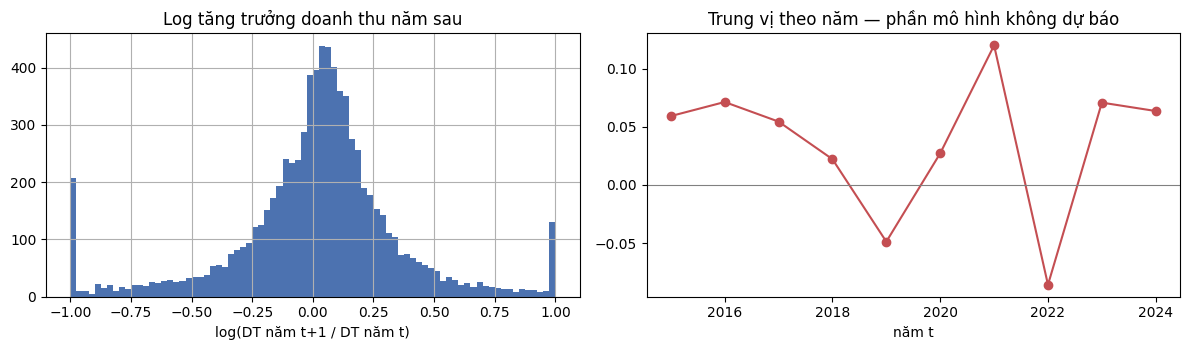

In [15]:
FEATURES = feature_columns(panel)
CLIP = 1.0  # log tăng trưởng bị cắt ở ±1 (khoảng −63% … +172%) để M&A và thoái vốn không chi phối

data = panel[panel.has_target].copy()
data["y_abs"] = data.target.clip(-CLIP, CLIP)
data["year_median"] = data.groupby("year").y_abs.transform("median")
data["y"] = data.y_abs - data.year_median

DEV_END, TEST_YEARS = 2022, [2023, 2024]
dev = data[data.year <= DEV_END]
test = data[data.year.isin(TEST_YEARS)]
print(f"{len(FEATURES)} đặc trưng | dev (t ≤ {DEV_END}): {len(dev):,} dòng | test (t = {TEST_YEARS}): {len(test):,} dòng")
display(data.groupby("year").agg(so_dong=("y", "size"), trung_vi_tang_truong=("y_abs", "median"), do_lech_chuan=("y", "std")).T)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
data.y_abs.hist(bins=80, ax=ax[0], color="#4C72B0")
ax[0].set_title("Log tăng trưởng doanh thu năm sau")
ax[0].set_xlabel("log(DT năm t+1 / DT năm t)")
data.groupby("year").y_abs.median().plot(marker="o", ax=ax[1], color="#C44E52")
ax[1].axhline(0, color="grey", lw=0.8)
ax[1].set_title("Trung vị theo năm — phần mô hình không dự báo")
ax[1].set_xlabel("năm t")
plt.tight_layout()
plt.show()

## 3. Chọn cấu hình bằng cross-validation theo thời gian

Dữ liệu là chuỗi theo năm nên không xáo trộn ngẫu nhiên. Mỗi fold train trên các năm trước *T* và kiểm tra trên năm *T*, với *T* = 2019 … 2022. Số vòng boosting được chọn tại điểm sai số trung bình của bốn fold thấp nhất.

In [16]:
CV_YEARS = [2019, 2020, 2021, 2022]
BASE = dict(learning_rate=0.03, subsample=0.8, colsample_bytree=0.6, reg_lambda=5.0,
            tree_method="hist", objective="reg:squarederror", random_state=SEED, n_jobs=os.cpu_count())
GRID = [dict(max_depth=d, min_child_weight=w) for d in (3, 4, 6) for w in (10, 30)]
MAX_ROUNDS = 800


def forward_cv(df, params, years=CV_YEARS, rounds=MAX_ROUNDS):
    """MAE trung bình theo số vòng boosting, qua các fold tiến theo thời gian."""
    curves = []
    for T in years:
        tr, va = df[df.year < T], df[df.year == T]
        m = xgb.XGBRegressor(n_estimators=rounds, eval_metric="mae", **BASE, **params)
        m.fit(tr[FEATURES], tr.y, eval_set=[(va[FEATURES], va.y)], verbose=False)
        curves.append(m.evals_result()["validation_0"]["mae"])
    return np.mean(curves, axis=0)


rows = []
for params in GRID:
    curve = forward_cv(dev, params)
    rows.append({**params, "rounds": int(curve.argmin()) + 1, "cv_mae": curve.min()})
cv_table = pd.DataFrame(rows).sort_values("cv_mae").reset_index(drop=True)
display(cv_table)

best = cv_table.iloc[0]
PARAMS = dict(max_depth=int(best.max_depth), min_child_weight=int(best.min_child_weight))
ROUNDS = int(best.rounds)
print("Chọn:", PARAMS, "| số vòng:", ROUNDS)


def fit_model(df, seed=SEED):
    return xgb.XGBRegressor(n_estimators=ROUNDS, **{**BASE, "random_state": seed}, **PARAMS).fit(df[FEATURES], df.y)

,max_depth,min_child_weight,rounds,cv_mae
0,3,30,96,0.245
1,4,30,90,0.245
2,6,30,77,0.245
3,6,10,74,0.245
4,3,10,97,0.245
5,4,10,74,0.246


Chọn: {'max_depth': 3, 'min_child_weight': 30} | số vòng: 96


## 4. Kết quả trên tập test

Tập test là hai năm mô hình chưa từng thấy: 2023→2024 và 2024→2025. So với bốn baseline:

- **Bằng mặt bằng chung:** mọi công ty tăng đúng bằng trung vị năm (dự báo 0).
- **Giữ nguyên đà:** năm sau lệch khỏi mặt bằng chung đúng như năm nay.
- **Theo ngành:** năm sau lệch đúng bằng mức ngành đang lệch.
- **Ridge:** hồi quy tuyến tính trên cùng bộ đặc trưng.

**IC** là tương quan hạng Spearman giữa dự báo và thực tế trong từng năm: đo khả năng xếp đúng thứ tự công ty tăng nhanh / chậm.

In [17]:
model = fit_model(dev)
ridge = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), RidgeCV(alphas=np.logspace(-1, 4, 20)))
ridge.fit(dev[FEATURES], dev.y)


def rel_now(df):
    """Tăng trưởng năm nay so với trung vị năm nay, cùng thang log với nhãn."""
    return (np.log1p(df.rev_g.clip(-0.6, 1.7)) - np.log1p(df.market_rev_g)).fillna(0)


def predictions(df):
    return {
        "Bằng mặt bằng chung": np.zeros(len(df)),
        "Giữ nguyên đà": rel_now(df).values,
        "Theo ngành": (np.log1p(df.sector_rev_g.fillna(df.market_rev_g)) - np.log1p(df.market_rev_g)).values,
        "Ridge": ridge.predict(df[FEATURES]),
        "XGBoost": model.predict(df[FEATURES]),
    }


def score(df, preds):
    rows = []
    zero_mae = np.abs(df.y).mean()
    for name, p in preds.items():
        p = np.clip(p, -CLIP, CLIP)
        ics = [spearmanr(p[(df.year == yr).values], df.y[df.year == yr]).statistic for yr in sorted(df.year.unique())] if np.std(p) > 0 else [np.nan]
        mae = np.abs(df.y - p).mean()
        rows.append({"mô hình": name, "MAE": mae, "cải thiện so với mặt bằng chung": 1 - mae / zero_mae,
                     "RMSE": np.sqrt(((df.y - p) ** 2).mean()), "IC trung bình": np.mean(ics)})
    return pd.DataFrame(rows).set_index("mô hình")


test_preds = predictions(test)
test_scores = score(test, test_preds)
display(test_scores)

,MAE,cải thiện so với mặt bằng chung,RMSE,IC trung bình
mô hình,,,,
Bằng mặt bằng chung,0.207,0.000,0.318,NaN
Giữ nguyên đà,0.296,-0.425,0.456,0.038
Theo ngành,0.212,-0.022,0.321,-0.028
Ridge,0.210,-0.012,0.315,0.171
XGBoost,0.201,0.029,0.304,0.269


Cách đọc dễ hơn: chia công ty trong tập test thành 5 nhóm theo dự báo, rồi xem tăng trưởng thực tế của từng nhóm. Nếu mô hình có ích thì nhóm được dự báo cao nhất phải tăng thật sự nhanh hơn nhóm thấp nhất.

,du_bao,thuc_te,so_cong_ty
nhom,,,
1,-0.120,-0.076,386
2,-0.047,-0.030,386
3,-0.014,-0.005,385
4,0.007,0.018,386
5,0.037,0.069,386


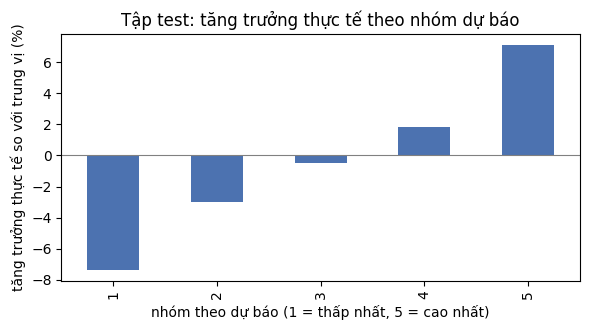

In [18]:
q = test.assign(pred=test_preds["XGBoost"])
q["nhom"] = q.groupby("year").pred.transform(lambda s: pd.qcut(s, 5, labels=False, duplicates="drop")) + 1
by_q = q.groupby("nhom").agg(du_bao=("pred", "median"), thuc_te=("y", "median"), so_cong_ty=("y", "size"))
display(by_q)

fig, ax = plt.subplots(figsize=(6, 3.4))
(np.expm1(by_q.thuc_te) * 100).plot.bar(ax=ax, color="#4C72B0")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("nhóm theo dự báo (1 = thấp nhất, 5 = cao nhất)")
ax.set_ylabel("tăng trưởng thực tế so với trung vị (%)")
ax.set_title("Tập test: tăng trưởng thực tế theo nhóm dự báo")
plt.tight_layout()
plt.show()

### Backtest tiến dần

Lặp lại cho từng năm: train trên mọi năm trước *T*, dự báo năm *T*. Một năm test tốt có thể là may; sáu năm thì khó may hơn.

Lưu ý: các năm 2019–2022 cũng là các fold đã dùng để chọn cấu hình ở mục 3, nên chỉ 2023 và 2024 là hoàn toàn ngoài mẫu.

In [19]:
rows, oof = [], []
for T in range(2019, 2025):
    tr, te = data[data.year < T], data[data.year == T]
    m = fit_model(tr)
    p = m.predict(te[FEATURES])
    oof.append(te[["ticker", "year", "y", "rev_g_3y_std"]].assign(pred=p))
    rows.append({"năm t": T, "số công ty": len(te), "MAE mặt bằng chung": np.abs(te.y).mean(), "MAE XGBoost": np.abs(te.y - p).mean(),
                 "IC": spearmanr(p, te.y).statistic})
walk = pd.DataFrame(rows).set_index("năm t")
walk["cải thiện"] = 1 - walk["MAE XGBoost"] / walk["MAE mặt bằng chung"]
display(walk)
oof = pd.concat(oof)

,số công ty,MAE mặt bằng chung,MAE XGBoost,IC,cải thiện
năm t,,,,,
2019,888,0.255,0.239,0.324,0.060
2020,924,0.258,0.251,0.212,0.030
2021,803,0.254,0.249,0.166,0.023
2022,760,0.242,0.240,0.203,0.009
2023,839,0.210,0.201,0.322,0.040
2024,1090,0.206,0.201,0.228,0.023


## 5. Khoảng dự báo (conformal)

Một con số dự báo mà không kèm độ chắc chắn thì dễ gây hiểu lầm. Cách làm: lấy sai số tuyệt đối của các dự báo ngoài mẫu trong giai đoạn dev (backtest 2019–2022), rồi dùng phân vị 80% của chúng làm bán kính khoảng.

Một bán kính chung cho mọi công ty thì quá thô: công ty có doanh thu ổn định dễ dự báo hơn hẳn công ty lên xuống thất thường. Vì vậy bán kính được tính riêng cho từng nhóm theo **độ biến động tăng trưởng 3 năm gần nhất** của chính công ty đó (Mondrian conformal). Sau đó kiểm tra trên tập test xem mỗi nhóm có thật sự phủ khoảng 80% giá trị thực không.

In [20]:
COVERAGE = 0.80
VOL_BINS = [-np.inf, 0.05, 0.10, 0.20, 0.40, np.inf]
VOL_LABELS = ["≤ 5%", "5–10%", "10–20%", "20–40%", "> 40%"]
NO_HISTORY = "thiếu lịch sử"


def vol_group(df):
    """Nhóm theo độ lệch chuẩn tăng trưởng doanh thu 3 năm; công ty mới thì vào nhóm riêng."""
    return pd.cut(df.rev_g_3y_std, VOL_BINS, labels=VOL_LABELS).astype(object).fillna(NO_HISTORY)


def conformal_radius(abs_resid, coverage=COVERAGE):
    r = np.sort(np.asarray(abs_resid))
    k = int(np.ceil((len(r) + 1) * coverage)) - 1
    return float(r[min(k, len(r) - 1)])


oof["group"] = vol_group(oof)
oof["abs_resid"] = (oof.y - oof.pred).abs()
calib = oof[oof.year <= DEV_END]
RADIUS = calib.groupby("group").abs_resid.apply(conformal_radius)
RADIUS_GLOBAL = conformal_radius(calib.abs_resid)

t = test.assign(pred=test_preds["XGBoost"])
t["group"] = vol_group(t)
t["covered"] = (t.y - t.pred).abs() <= t.group.map(RADIUS)
order = VOL_LABELS + [NO_HISTORY]
interval_table = pd.DataFrame({
    "số dòng hiệu chỉnh": calib.groupby("group").size(),
    "bán kính (log)": RADIUS,
    "cận dưới": np.expm1(-RADIUS),
    "cận trên": np.expm1(RADIUS),
    "số dòng test": t.groupby("group").size(),
    "tỷ lệ phủ trên test": t.groupby("group").covered.mean(),
}).reindex(order)
display(interval_table)
covered = float(t.covered.mean())
covered_global = float(((t.y - t.pred).abs() <= RADIUS_GLOBAL).mean())
print(f"Tỷ lệ phủ trên toàn tập test: {covered:.1%} (mục tiêu {COVERAGE:.0%})")
print(f"Nếu dùng một bán kính chung ±{RADIUS_GLOBAL:.3f}: phủ {covered_global:.1%}, nhưng quá rộng với công ty ổn định và quá hẹp với công ty biến động")

,số dòng hiệu chỉnh,bán kính (log),cận dưới,cận trên,số dòng test,tỷ lệ phủ trên test
group,,,,,,
≤ 5%,327,0.230,-0.206,0.259,158,0.861
5–10%,489,0.256,-0.226,0.292,196,0.837
10–20%,861,0.318,-0.272,0.374,444,0.885
20–40%,794,0.438,-0.355,0.550,508,0.892
> 40%,706,0.651,-0.478,0.917,464,0.853
thiếu lịch sử,198,0.369,-0.308,0.446,159,0.862


Tỷ lệ phủ trên toàn tập test: 87.0% (mục tiêu 80%)
Nếu dùng một bán kính chung ±0.398: phủ 86.0%, nhưng quá rộng với công ty ổn định và quá hẹp với công ty biến động


## 6. Giải thích mô hình bằng SHAP

Giá trị SHAP cho biết mỗi đặc trưng đẩy dự báo của một công ty lên hay xuống bao nhiêu so với mức trung bình. Ở đây dùng TreeSHAP có sẵn trong XGBoost (`pred_contribs`), cho kết quả chính xác với mô hình cây.

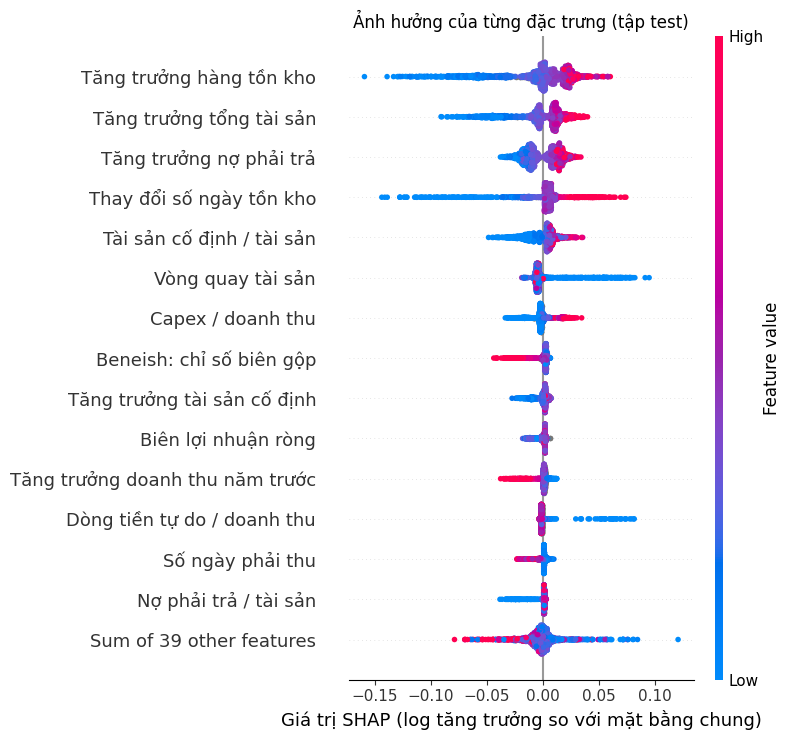

,trung bình |SHAP|
Tăng trưởng hàng tồn kho,0.022
Tăng trưởng tổng tài sản,0.016
Tăng trưởng nợ phải trả,0.013
Thay đổi số ngày tồn kho,0.012
Tài sản cố định / tài sản,0.009
Vòng quay tài sản,0.009
Capex / doanh thu,0.005
Beneish: chỉ số biên gộp,0.004
Tăng trưởng tài sản cố định,0.003
Biên lợi nhuận ròng,0.003


In [21]:
try:
    import shap
except ImportError:
    os.system(f"{sys.executable} -m pip install -q shap")
    import shap


def shap_values(m, X):
    """Trả về (giá trị SHAP, giá trị nền). Tổng mỗi dòng + nền = dự báo."""
    contrib = m.get_booster().predict(xgb.DMatrix(X[FEATURES]), pred_contribs=True)
    return contrib[:, :-1], float(contrib[0, -1])


LABELS = [FEATURE_LABELS.get(f, f) for f in FEATURES]
sv, base_value = shap_values(model, test)
explanation = shap.Explanation(values=sv, base_values=np.full(len(test), base_value), data=test[FEATURES].values, feature_names=LABELS)
global_imp = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).sort_values(ascending=False)

shap.plots.beeswarm(explanation, max_display=15, show=False)
plt.title("Ảnh hưởng của từng đặc trưng (tập test)")
plt.xlabel("Giá trị SHAP (log tăng trưởng so với mặt bằng chung)")
plt.tight_layout()
plt.show()
display(global_imp.head(15).rename(FEATURE_LABELS).to_frame("trung bình |SHAP|"))

### Giải thích cho một công ty

Dự báo cho năm 2026 dùng đặc trưng của năm 2025. Mô hình cuối được train lại trên toàn bộ dữ liệu có nhãn (đến 2024→2025).

FPT: doanh thu 2025 = 70,113 tỷ
  Giả định mặt bằng chung 2026: +5.9%
  Mô hình: FPT lệch +3.7% so với mặt bằng chung (nhóm biến động: ≤ 5%)
  Tăng trưởng 2026: +9.8% (khoảng 80%: -12.8% đến +38.2%)
  Doanh thu 2026: 76,960 tỷ (khoảng: 61,131 – 96,888 tỷ)


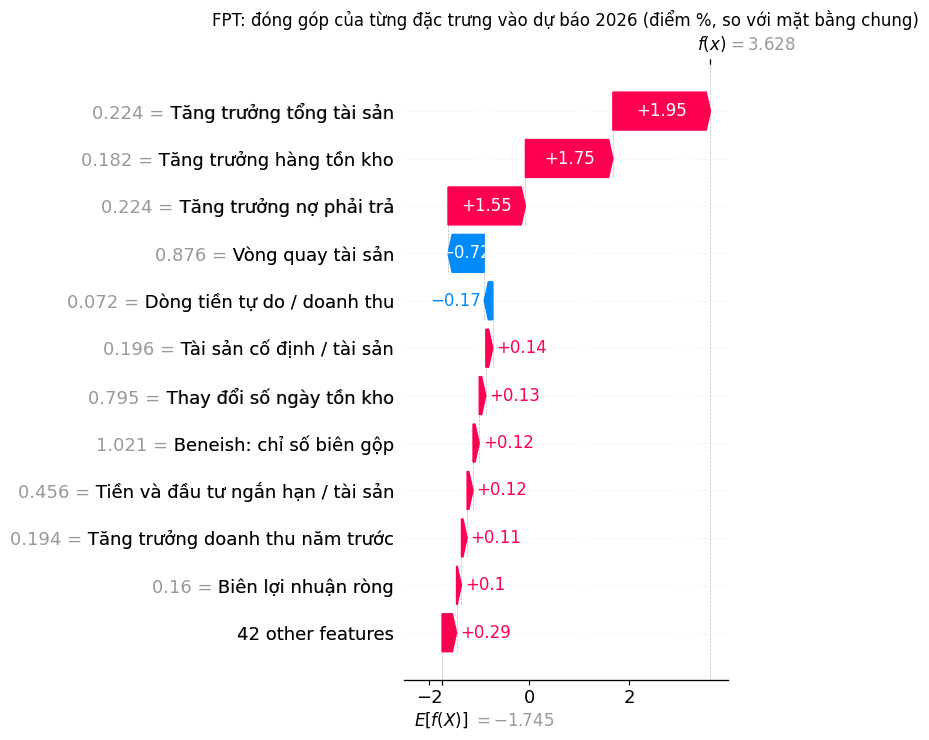

In [22]:
final_model = fit_model(data)
latest_year = int(panel.year.max())
latest = panel[(panel.year == latest_year) & panel.usable].copy()
latest["pred_rel"] = final_model.predict(latest[FEATURES])

# mặt bằng chung là giả định, không phải dự báo: lấy trung vị của các trung vị năm trong quá khứ
MARKET_ASSUMPTION = float(data.groupby("year").y_abs.median().median())
latest["vol_group"] = vol_group(latest)
latest["radius"] = latest.vol_group.map(RADIUS).astype(float)
latest["growth_mid"] = np.expm1(MARKET_ASSUMPTION + latest.pred_rel)
latest["growth_lo"] = np.expm1(MARKET_ASSUMPTION + latest.pred_rel - latest.radius)
latest["growth_hi"] = np.expm1(MARKET_ASSUMPTION + latest.pred_rel + latest.radius)
latest["revenue_next_mid"] = latest.revenue * (1 + latest.growth_mid)

row = latest[latest.ticker == FOCUS]
if len(row):
    r = row.iloc[0]
    print(f"{FOCUS}: doanh thu {latest_year} = {r.revenue / 1e9:,.0f} tỷ")
    print(f"  Giả định mặt bằng chung {latest_year + 1}: {np.expm1(MARKET_ASSUMPTION):+.1%}")
    print(f"  Mô hình: {FOCUS} lệch {np.expm1(r.pred_rel):+.1%} so với mặt bằng chung (nhóm biến động: {r.vol_group})")
    print(f"  Tăng trưởng {latest_year + 1}: {r.growth_mid:+.1%} (khoảng {COVERAGE:.0%}: {r.growth_lo:+.1%} đến {r.growth_hi:+.1%})")
    print(f"  Doanh thu {latest_year + 1}: {r.revenue_next_mid / 1e9:,.0f} tỷ (khoảng: {r.revenue * (1 + r.growth_lo) / 1e9:,.0f} – {r.revenue * (1 + r.growth_hi) / 1e9:,.0f} tỷ)")

    sv_f, base_f = shap_values(final_model, row)
    # nhân 100 để đọc theo điểm phần trăm; ở thang log gốc các giá trị quá nhỏ và bị làm tròn về 0
    shap.plots.waterfall(shap.Explanation(values=sv_f[0] * 100, base_values=base_f * 100, data=row[FEATURES].values[0], feature_names=LABELS), max_display=12, show=False)
    plt.title(f"{FOCUS}: đóng góp của từng đặc trưng vào dự báo {latest_year + 1} (điểm %, so với mặt bằng chung)")
    plt.tight_layout()
    plt.show()

### Lời giải thích có ổn định không?

Nếu train lại trên một mẫu dữ liệu hơi khác mà danh sách "yếu tố quan trọng nhất" đổi hẳn thì lời giải thích đó không đáng tin. Ở đây train lại 30 lần, mỗi lần lấy mẫu lại **theo công ty** (bootstrap theo cụm), rồi đo:

- Thứ hạng độ quan trọng toàn cục có giống nhau giữa các lần không (tương quan hạng Spearman).
- Top 10 đặc trưng trùng nhau bao nhiêu.
- Với công ty ví dụ: giá trị SHAP của từng đặc trưng dao động bao nhiêu, và có giữ nguyên dấu không.

Tương quan hạng giữa các lần train: trung bình 0.59, thấp nhất 0.33
Top 10 trùng với mô hình chính: trung bình 75%


,mô hình chính,bootstrap trung bình,bootstrap độ lệch chuẩn,hệ số biến thiên
Tăng trưởng hàng tồn kho,0.022,0.020,0.004,0.190
Tăng trưởng tổng tài sản,0.016,0.016,0.004,0.227
Tăng trưởng nợ phải trả,0.013,0.016,0.005,0.339
Thay đổi số ngày tồn kho,0.012,0.010,0.002,0.207
Tài sản cố định / tài sản,0.009,0.005,0.002,0.391
Vòng quay tài sản,0.009,0.010,0.003,0.270
Capex / doanh thu,0.005,0.006,0.002,0.386
Beneish: chỉ số biên gộp,0.004,0.003,0.002,0.720
Tăng trưởng tài sản cố định,0.003,0.003,0.002,0.764
Biên lợi nhuận ròng,0.003,0.001,0.001,0.823



FPT: dự báo lệch so với mặt bằng chung qua 30 lần train: +0.032 ± 0.008 log


,giá trị,SHAP mô hình chính,SHAP bootstrap trung bình,độ lệch chuẩn,cùng dấu với mô hình chính
Tăng trưởng tổng tài sản,0.224,0.020,0.015,0.006,1.000
Tăng trưởng hàng tồn kho,0.182,0.018,0.014,0.006,1.000
Tăng trưởng nợ phải trả,0.224,0.015,0.016,0.006,1.000
Vòng quay tài sản,0.876,-0.007,-0.007,0.002,1.000
Dòng tiền tự do / doanh thu,0.072,-0.002,-0.001,0.001,0.967
Tài sản cố định / tài sản,0.196,0.001,0.001,0.001,0.933
Thay đổi số ngày tồn kho,0.795,0.001,0.002,0.002,0.867
Beneish: chỉ số biên gộp,1.021,0.001,0.001,0.001,1.000
Tiền và đầu tư ngắn hạn / tài sản,0.456,0.001,0.000,0.001,0.867
Tăng trưởng doanh thu năm trước,0.194,0.001,0.000,0.001,0.633


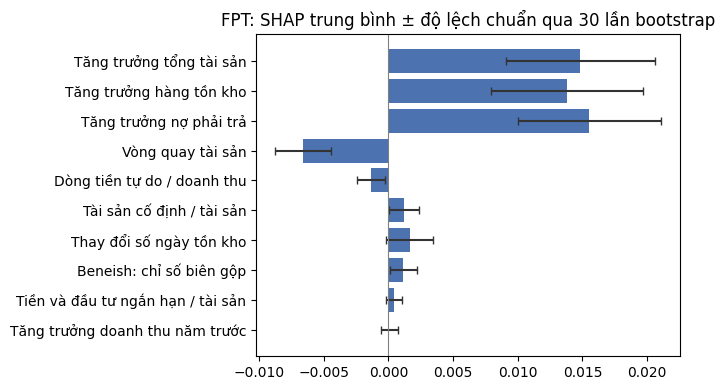

In [23]:
N_BOOT = 30
rng = np.random.default_rng(SEED)
tickers = data.ticker.unique()
by_ticker = {t: g for t, g in data.groupby("ticker")}
boot_imp, boot_local, boot_pred = [], [], []
for b in range(N_BOOT):
    sample = pd.concat([by_ticker[t] for t in rng.choice(tickers, len(tickers), replace=True)])
    m = fit_model(sample, seed=SEED + 1 + b)
    s, _ = shap_values(m, test)
    boot_imp.append(np.abs(s).mean(axis=0))
    if len(row):
        s_f, _ = shap_values(m, row)
        boot_local.append(s_f[0])
        boot_pred.append(float(m.predict(row[FEATURES])[0]))
boot_imp = pd.DataFrame(boot_imp, columns=FEATURES)

rank_corr = boot_imp.T.corr(method="spearman").values
pairwise = rank_corr[np.triu_indices(N_BOOT, k=1)]
top10 = set(global_imp.index[:10])
overlap = [len(top10 & set(boot_imp.iloc[b].sort_values(ascending=False).index[:10])) / 10 for b in range(N_BOOT)]
stability = {"rank_corr_mean": float(pairwise.mean()), "rank_corr_min": float(pairwise.min()), "top10_overlap_mean": float(np.mean(overlap))}
print(f"Tương quan hạng giữa các lần train: trung bình {stability['rank_corr_mean']:.2f}, thấp nhất {stability['rank_corr_min']:.2f}")
print(f"Top 10 trùng với mô hình chính: trung bình {stability['top10_overlap_mean']:.0%}")

imp_summary = pd.DataFrame({"mô hình chính": global_imp, "bootstrap trung bình": boot_imp.mean(), "bootstrap độ lệch chuẩn": boot_imp.std()})
imp_summary["hệ số biến thiên"] = imp_summary["bootstrap độ lệch chuẩn"] / imp_summary["bootstrap trung bình"]
display(imp_summary.sort_values("mô hình chính", ascending=False).head(12).rename(FEATURE_LABELS))

local_summary = None
if len(row):
    boot_local = pd.DataFrame(boot_local, columns=FEATURES)
    local_summary = pd.DataFrame({
        "giá trị": row[FEATURES].iloc[0],
        "SHAP mô hình chính": sv_f[0],
        "SHAP bootstrap trung bình": boot_local.mean(),
        "độ lệch chuẩn": boot_local.std(),
        "cùng dấu với mô hình chính": (np.sign(boot_local) == np.sign(sv_f[0])).mean(),
    }, index=FEATURES)
    local_summary = local_summary.reindex(local_summary["SHAP mô hình chính"].abs().sort_values(ascending=False).index)
    print(f"\n{FOCUS}: dự báo lệch so với mặt bằng chung qua {N_BOOT} lần train: {np.mean(boot_pred):+.3f} ± {np.std(boot_pred):.3f} log")
    display(local_summary.head(10).rename(FEATURE_LABELS))

    top = local_summary.head(10).iloc[::-1].rename(FEATURE_LABELS)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(top.index, top["SHAP bootstrap trung bình"], xerr=top["độ lệch chuẩn"], color="#4C72B0", ecolor="#333", capsize=3)
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_title(f"{FOCUS}: SHAP trung bình ± độ lệch chuẩn qua {N_BOOT} lần bootstrap")
    plt.tight_layout()
    plt.show()

## 7. Tín hiệu rủi ro kế toán: Beneish M-Score

M-Score (Beneish, 1999) gộp tám tỷ số thành một điểm; trên −1,78 thường được coi là dấu hiệu nên xem kỹ chất lượng lợi nhuận. Đây là công thức cố định, không train. Ngưỡng được ước lượng trên doanh nghiệp Mỹ nên ở đây chỉ dùng để **xếp hạng trong cùng ngành, cùng năm**, không dùng như kết luận.

In [24]:
risk = panel[panel.usable & panel.m_score.notna()].copy()
risk["m_pct_in_sector"] = risk.groupby(["sector", "year"]).m_score.rank(pct=True)
risk["accruals_pct_in_sector"] = risk.groupby(["sector", "year"]).accruals.rank(pct=True)
print(f"Tỷ lệ công ty–năm có M-Score > −1,78: {(risk.m_score > -1.78).mean():.1%}")
cols = ["m_score", "m_pct_in_sector", "accruals", "accruals_pct_in_sector", "dsri", "gmi", "aqi", "depi", "sgai", "lvgi"]
display(risk[risk.ticker == FOCUS].set_index("year")[cols].T)

Tỷ lệ công ty–năm có M-Score > −1,78: 26.7%


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
m_score,-2.229,-2.753,-1.992,-2.276,-2.318,-2.823,-2.498,-2.020,-2.486,-2.460,-2.277
m_pct_in_sector,0.462,0.533,0.800,0.500,0.533,0.533,0.533,0.500,0.353,0.471,0.412
accruals,0.046,-0.062,0.056,-0.013,0.000,-0.051,-0.010,0.027,-0.031,-0.034,0.014
accruals_pct_in_sector,0.615,0.400,0.733,0.357,0.533,0.533,0.467,0.571,0.353,0.294,0.529
dsri,0.906,1.032,0.970,2.028,0.875,0.889,0.934,1.042,0.948,0.974,1.083
gmi,1.066,0.925,0.940,0.604,0.972,0.976,1.019,0.980,1.010,1.024,1.021
aqi,0.907,1.042,1.321,1.101,1.275,0.902,0.780,1.103,0.981,0.982,0.892
depi,1.009,0.863,1.022,1.090,0.991,1.008,1.113,1.033,0.921,0.982,1.013
sgai,1.004,1.135,1.120,1.580,0.982,1.020,0.980,1.023,0.957,0.930,1.013
lvgi,1.116,1.018,0.766,1.067,0.989,1.121,1.081,0.843,0.984,0.991,1.004


## 8. Lưu artifact

App sẽ đọc các file này thay vì train lại. Trên Kaggle chúng nằm ở `/kaggle/working/artifacts` (tab Output).

In [25]:
final_model.get_booster().save_model(str(OUT_DIR / "growth_model.json"))

pred_cols = ["ticker", "year", "sector", "exchange", "revenue", "pred_rel", "vol_group", "radius", "growth_lo", "growth_mid", "growth_hi", "revenue_next_mid"]
latest[[c for c in pred_cols if c in latest]].sort_values("pred_rel", ascending=False).to_csv(OUT_DIR / f"predictions_{latest_year + 1}.csv", index=False)

risk_cols = ["ticker", "year", "sector", "m_score", "m_pct_in_sector", "accruals", "accruals_pct_in_sector", "dso_chg", "recv_minus_rev_g"]
risk[risk_cols].to_csv(OUT_DIR / "risk_scores.csv", index=False)
imp_summary.sort_values("mô hình chính", ascending=False).to_csv(OUT_DIR / "shap_global.csv")
if local_summary is not None:
    local_summary.to_csv(OUT_DIR / f"shap_{FOCUS}_{latest_year + 1}.csv")

xgb_test = test_scores.loc["XGBoost"]
metrics = {
    "target": "log revenue growth t→t+1 minus the cross-sectional median of that year, clipped at ±%.1f" % CLIP,
    "features": FEATURES,
    "feature_labels": {f: FEATURE_LABELS.get(f, f) for f in FEATURES},
    "params": {**PARAMS, "rounds": ROUNDS, **{k: v for k, v in BASE.items() if k not in ("n_jobs", "random_state")}},
    "rows": {"dev": len(dev), "test": len(test), "final_fit": len(data), "predicted": len(latest)},
    "test": {"mae": float(xgb_test["MAE"]), "mae_market_baseline": float(test_scores.loc["Bằng mặt bằng chung", "MAE"]),
             "improvement": float(xgb_test["cải thiện so với mặt bằng chung"]), "ic": float(xgb_test["IC trung bình"])},
    "walk_forward": walk.reset_index().rename(columns={"năm t": "year", "số công ty": "n", "MAE mặt bằng chung": "mae_market", "MAE XGBoost": "mae_xgb", "cải thiện": "improvement"}).to_dict("records"),
    "interval": {"coverage_target": COVERAGE, "group_by": "rev_g_3y_std", "bins": VOL_BINS[1:-1], "labels": order,
                 "radius_log": {g: float(RADIUS[g]) for g in order if g in RADIUS}, "coverage_on_test": covered},
    "market_assumption_log": MARKET_ASSUMPTION,
    "shap_stability": stability,
    "base_value": base_f if len(row) else None,
}
(OUT_DIR / "metrics.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2))
print("Đã lưu:", sorted(p.name for p in OUT_DIR.iterdir()))

Đã lưu: ['growth_model.json', 'metrics.json', 'predictions_2026.csv', 'risk_scores.csv', 'shap_FPT_2026.csv', 'shap_global.csv']


## Đọc kết quả thế nào

- **Mô hình xếp hạng được, nhưng không đoán được con số.** IC dương nghĩa là nó phân biệt được nhóm tăng nhanh với nhóm tăng chậm (xem bảng backtest và biểu đồ 5 nhóm). Nhưng MAE chỉ nhỉnh hơn baseline "ai cũng tăng bằng mặt bằng chung" vài phần trăm, và khoảng dự báo 80% rất rộng ngay cả với nhóm ổn định nhất. Tăng trưởng doanh thu một năm tới phần lớn không nằm trong BCTC năm nay.
- **Baseline "giữ nguyên đà" thua xa.** Công ty vừa tăng mạnh thường tăng chậm lại, nên kéo dài xu hướng là cách dự báo tệ nhất ở đây.
- **Con số tuyệt đối phụ thuộc vào giả định mặt bằng chung.** Mô hình chỉ nói công ty lệch bao nhiêu so với số đông.
- **Giới hạn dữ liệu:** số liệu đến từ OCR; các dòng không khớp đẳng thức kế toán đã bị loại, nhưng lỗi ở dòng không có đẳng thức kiểm tra thì vẫn lọt. Bộ dữ liệu thiếu một số mã (ví dụ CMG) và không có ngân hàng, chứng khoán, bảo hiểm trong mô hình.

Trong báo cáo của agent, mục Forecast nên ghi mức tin cậy **thấp** và luôn kèm khoảng dự báo.